In [1]:
# Installation rapide
!pip install polars s3fs boto3 pyarrow pandas openpyxl --quiet


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


# Chargement des packages 

In [2]:
import boto3
import pandas as pd
import numpy as np
from io import BytesIO, StringIO
import re
import io
import os

In [3]:
s3_client = boto3.client(
 "s3",
 endpoint_url="http://minio.mon-namespace.svc.cluster.local:80", # service interne K8s
 aws_access_key_id="wer1Or8j7hXa3QGk2M3M",
 aws_secret_access_key="YtbyBd3Y0bEYeDy8aeX3lAf4JIUlKYlxY8lNVTVt",
 verify=False # à désactiver si SSL auto-signé ; sinon mettre True avec certificat valide
)

In [4]:
# Paramètres
bucket_name = "admindataanstat"
object_key = "Solde/panel_solde_df.csv"  # Chemin dans le bucket

In [5]:
obj = s3_client.get_object(Bucket=bucket_name, Key=object_key)
panel_solde_df = pd.read_csv(io.BytesIO(obj["Body"].read()), encoding="utf-8-sig")


In [6]:
# Affiche les 5 premières lignes pour un aperçu rapide.
panel_solde_df.head()

,MATRICULE||CODE_ORGANISME,MATRICULE,NOM,DATE NAISSANCE,SEXE,SITUATION MATRIMONIALE,NOMBRE ENFANT,LIEU AFFECTATION,SERVICE,ORGANISME,...,MONTANT NET,RETENUE PENSION,IMPOT,CHARGE PATRONALE,MOIS/ANNEE,GRADE 2,AGE RETRAITE,DATE RETRAITE,PERIODE,DATE_COLLECTE
0,011242X15,011242X,DOSSO MEGBO,1939-01-01 00:00:00,Masculin,Marié,0.0,Seguela,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,34145,0.0,415.0,0.0,12015,60,NaN,NaN,12015,2015-01-01
1,012856Q15,012856Q,KHISSY BEYNIOUAH FULBERT,1939-01-01 00:00:00,Masculin,Célibataire,0.0,Bouaké,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,41582,0.0,509.0,0.0,12015,60,NaN,NaN,12015,2015-01-01
2,013454N15,013454N,VAHA TOMAS GNOMBLEI HENRI,1924-01-01 00:00:00,Masculin,Marié,0.0,Guiglo,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,45053,0.0,547.0,0.0,12015,60,NaN,NaN,12015,2015-01-01
3,027861L25,027861L,CAPET YATO MATHIEU,1943-03-01 00:00:00,Masculin,Marié,0.0,Abidjan,A affecter,"Min. Affaires Etrangères, de l'Intégration Afr...",...,662121,0.0,9600.0,0.0,12015,60,NaN,NaN,12015,2015-01-01
4,039659M38,039659M,COULIBALY YOUSSOUF,1945-12-01 00:00:00,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,810000,0.0,0.0,0.0,12015,A7,NaN,NaN,12015,2015-01-01


In [7]:
# Afficher la liste des variable de ma base de données
print(panel_solde_df.columns)

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE'],
      dtype='object')



#                   MATRICULE ||CODE_ORGANISME                   #


In [8]:
# Examen de la variable MATRICULE||CODE_ORGANISME
panel_solde_df["MATRICULE||CODE_ORGANISME"].describe()

count      15627963
unique       308240
top       612155S15
freq             72
Name: MATRICULE||CODE_ORGANISME, dtype: object

In [9]:
# Créer une nouvelle colonne qui compte le nombre de position de la variable MATRICULE
panel_solde_df["nb_digits_mat"] = panel_solde_df["MATRICULE||CODE_ORGANISME"].str.len()
print(panel_solde_df["nb_digits_mat"])

0           9
1           9
2           9
3           9
4           9
           ..
15627958    9
15627959    9
15627960    9
15627961    9
15627962    9
Name: nb_digits_mat, Length: 15627963, dtype: int64


In [10]:
# Filtrer les lignes où le code ne tient pas sur 9 chiffres
codes_invalides = panel_solde_df[panel_solde_df["nb_digits_mat"] != 9]
print(codes_invalides[["MATRICULE||CODE_ORGANISME", "nb_digits_mat"]])  
# Tous les individus de notre base ont un matricule et code organisme qui tient sur 9 positions (Matricule + code organisme).

Empty DataFrame
Columns: [MATRICULE||CODE_ORGANISME, nb_digits_mat]
Index: []


In [11]:
# Suppression de la variable nombre de digit de la variable MATRICULE||CODE_ORGANISME
panel_solde_df = panel_solde_df.drop(columns=["nb_digits_mat"])

In [12]:
# Extraire les 7 premiers caractères pour le MATRICULE
panel_solde_df["MATRICULE_Verif"] = panel_solde_df["MATRICULE||CODE_ORGANISME"].str[:7]

# Extraire les caractères à partir de la position 7 pour le CODE_ORGANISME
panel_solde_df["CODE_ORGANISME"] = panel_solde_df["MATRICULE||CODE_ORGANISME"].str[7:]

In [13]:
panel_solde_df["MATRICULE_Verif"].str.len()

0           7
1           7
2           7
3           7
4           7
           ..
15627958    7
15627959    7
15627960    7
15627961    7
15627962    7
Name: MATRICULE_Verif, Length: 15627963, dtype: int64

In [14]:
panel_solde_df["CODE_ORGANISME"].str.len()

0           2
1           2
2           2
3           2
4           2
           ..
15627958    2
15627959    2
15627960    2
15627961    2
15627962    2
Name: CODE_ORGANISME, Length: 15627963, dtype: int64

In [15]:
# Filtrer les lignes où le matricule obtenu est différent du matricule fourmi dans la base de données 
mat_diff = panel_solde_df[panel_solde_df["MATRICULE_Verif"] != panel_solde_df["MATRICULE"]]
mat_diff

,MATRICULE||CODE_ORGANISME,MATRICULE,NOM,DATE NAISSANCE,SEXE,SITUATION MATRIMONIALE,NOMBRE ENFANT,LIEU AFFECTATION,SERVICE,ORGANISME,...,IMPOT,CHARGE PATRONALE,MOIS/ANNEE,GRADE 2,AGE RETRAITE,DATE RETRAITE,PERIODE,DATE_COLLECTE,MATRICULE_Verif,CODE_ORGANISME


In [16]:
# Suppression de la variable MATRICULE VERIF
panel_solde_df = panel_solde_df.drop(columns=["MATRICULE_Verif"])
print(panel_solde_df.columns)

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE', 'CODE_ORGANISME'],
      dtype='object')



#                            DATE NAISSANCE                     #


In [17]:
# Examen de la variable Date de naissance
panel_solde_df["DATE NAISSANCE"].describe()

count                15620485
unique                  15455
top       1980-01-01 00:00:00
freq                   176217
Name: DATE NAISSANCE, dtype: object

In [18]:
# Conversion au format datetime
panel_solde_df["DATE NAISSANCE"] = pd.to_datetime(panel_solde_df["DATE NAISSANCE"], errors='coerce')


**Extraction de l'année, le mois et le jour**

In [19]:
panel_solde_df["ANNEE_NAISSANCE"] = panel_solde_df["DATE NAISSANCE"].dt.year
panel_solde_df["MOIS_NAISSANCE"] = panel_solde_df["DATE NAISSANCE"].dt.month
panel_solde_df["JOUR_NAISSANCE"] = panel_solde_df["DATE NAISSANCE"].dt.day

**Stat descriptive sur l'année, le mois , et le jour**

In [20]:
# # Création du tableau avec effectifs et pourcentages (y compris NaN)
tab_annee = panel_solde_df["ANNEE_NAISSANCE"].value_counts(dropna=False).sort_index()
tab_annee_pct = panel_solde_df["ANNEE_NAISSANCE"].value_counts(normalize=True, dropna=False).sort_index()

# Créer le DataFrame et l’assigner à une variable
df_tab = pd.DataFrame({
    "Effectif": tab_annee,
    "Pourcentage (%)": (tab_annee_pct * 100).round(2)
})
df_tab

,Effectif,Pourcentage (%)
ANNEE_NAISSANCE,,
1900.0,11,0.00
1924.0,60,0.00
1931.0,4,0.00
1933.0,6,0.00
1935.0,60,0.00
...,...,...
1999.0,443,0.00
2000.0,182,0.00
2011.0,17009,0.11


In [21]:
# # Création du tableau avec effectifs et pourcentages (y compris NaN)
tab_mois = panel_solde_df["MOIS_NAISSANCE"].value_counts(dropna=False).sort_index()
tab_mois_pct = panel_solde_df["MOIS_NAISSANCE"].value_counts(normalize=True, dropna=False).sort_index()

# Créer le DataFrame et l’assigner à une variable
pd.DataFrame({
    "Effectif": tab_mois,
    "Pourcentage (%)": (tab_mois_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
MOIS_NAISSANCE,,
1.0,2881377,18.44
2.0,926638,5.93
3.0,1114726,7.13
4.0,1059270,6.78
5.0,1098128,7.03
6.0,1099144,7.03
7.0,1009007,6.46
8.0,937539,6.00
9.0,909392,5.82


In [22]:
# # Création du tableau avec effectifs et pourcentages (y compris NaN)
tab_jour = panel_solde_df["JOUR_NAISSANCE"].value_counts(dropna=False).sort_index()
tab_jour_pct = panel_solde_df["JOUR_NAISSANCE"].value_counts(normalize=True, dropna=False).sort_index()

# Créer le DataFrame et l’assigner à une variable
pd.DataFrame({
    "Effectif": tab_jour,
    "Pourcentage (%)": (tab_jour_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
JOUR_NAISSANCE,,
1.0,5288630,33.84
2.0,354030,2.27
3.0,309203,1.98
4.0,304176,1.95
5.0,346069,2.21
6.0,290310,1.86
7.0,287207,1.84
8.0,301451,1.93
9.0,277218,1.77


In [23]:
# Création du buffer mémoire binaire pour Excel
excel_buffer = BytesIO()

# Écriture du DataFrame dans ce buffer
with pd.ExcelWriter(excel_buffer, engine='openpyxl') as writer:
        df_tab.to_excel(writer, index=True, sheet_name='Tab_AnneeNaissance')

# Remise à zéro du buffer pour lecture complète
excel_buffer.seek(0)

# Upload vers MinIO S3
s3_client.put_object(
    Bucket="admindataanstat",  # ton bucket
    Key="Solde/tabulation_annee_naissance.xlsx",  # chemin/fichier dans le bucket
    Body=excel_buffer.getvalue()
)

{'ResponseMetadata': {'RequestId': '185AC5ED6D73D851',
  'HostId': '47060e467e9946c124b3c42eac2b7a5f6d6d8f48ed221dcb6d440c170afc21bf',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'content-length': '0',
   'etag': '"1c74e347ef6ee6ae338b4b0bf985d4d8"',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-checksum-crc32': 't5QcLw==',
   'x-amz-id-2': '47060e467e9946c124b3c42eac2b7a5f6d6d8f48ed221dcb6d440c170afc21bf',
   'x-amz-request-id': '185AC5ED6D73D851',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '699',
   'x-ratelimit-remaining': '699',
   'x-xss-protection': '1; mode=block',
   'x-amz-version-id': '970e6042-1aa9-4a5a-b104-36e03e80ec86',
   'date': 'Mon, 11 Aug 2025 17:17:08 GMT'},
  'RetryAttempts': 0},
 'ETag': '"1c74e347ef6ee6ae338b4b0bf985d4d8"',
 'ChecksumCRC32': 't5QcLw==',
 'VersionId': '970e6042-1aa9-4a5a-b104-36e03e80ec86'}


#                            DATE COLLECTE                      #


In [24]:
# S'assurer que DATE_COLLECTE est bien au format datetime
panel_solde_df["DATE_COLLECTE"] = pd.to_datetime(panel_solde_df["DATE_COLLECTE"], errors='coerce')

**Extraction de l'année, le mois et le jour**

In [25]:
# Extraire l'année, le mois et le jour
panel_solde_df["ANNEE_COLLECTE"] = panel_solde_df["DATE_COLLECTE"].dt.year
panel_solde_df["MOIS_COLLECTE"] = panel_solde_df["DATE_COLLECTE"].dt.month
panel_solde_df["JOUR_COLLECTE"] = panel_solde_df["DATE_COLLECTE"].dt.day

# Conversion en numérique (float), les erreurs sont mises à NaN
panel_solde_df["ANNEE_COLLECTE"] = pd.to_numeric(panel_solde_df["ANNEE_COLLECTE"], errors="coerce")

**Stat descriptive sur l'année, le mois , et le jour**

In [26]:
# Tabulation de la variable année de collecte
tab_annee_collecte = panel_solde_df["ANNEE_COLLECTE"].value_counts(dropna=False).sort_index()
tab_annee_collecte_pct = panel_solde_df["ANNEE_COLLECTE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_annee_collecte,
    "Pourcentage (%)": (tab_annee_collecte_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
ANNEE_COLLECTE,,
2015,2304670,14.75
2016,2427817,15.54
2017,2509596,16.06
2018,2668828,17.08
2019,2795579,17.89
2020,2921473,18.69


In [27]:
# Tabulation de la variable mois de collecte
tab_mois_collecte = panel_solde_df["MOIS_COLLECTE"].value_counts(dropna=False).sort_index()
tab_mois_collecte_pct = panel_solde_df["MOIS_COLLECTE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_mois_collecte,
    "Pourcentage (%)": (tab_mois_collecte_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
MOIS_COLLECTE,,
1,1246407,7.98
2,1260660,8.07
3,1269924,8.13
4,1281866,8.20
5,1289817,8.25
6,1302055,8.33
7,1310055,8.38
8,1319467,8.44
9,1327515,8.49


In [28]:
# Tabulation de la variable mois de collecte
tab_jour_collecte = panel_solde_df["JOUR_COLLECTE"].value_counts(dropna=False).sort_index()
tab_jour_collecte_pct = panel_solde_df["JOUR_COLLECTE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_jour_collecte,
    "Pourcentage (%)": (tab_jour_collecte_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
JOUR_COLLECTE,,
1,15627963,100.0



#          METHODE DE MISE A JOUR DE LA DATE DE NAISSANCE       #


J'ai des données de panel mais je cherche à savoir si pour un individu j'ai plusieurs date de naissance en fonction de la date de collecte. Il peut mettre à jour ces informations


**Comptage des individus qui ont plus d'une date de naissance**

In [29]:
# Regrouper par identifiant individuel et compter le nombre de dates de naissance uniques
verif_naissance = panel_solde_df.groupby("MATRICULE")["DATE NAISSANCE"].nunique()

# Filtrer ceux ayant plus d'une date de naissance
individus_naissances_diff = verif_naissance[verif_naissance > 1]

# Afficher les identifiants concernés
individus_naissances_diff.describe().round(0)

count    50543.0
mean         2.0
std          0.0
min          2.0
25%          2.0
50%          2.0
75%          2.0
max          5.0
Name: DATE NAISSANCE, dtype: float64

**Comptage du nombre d'individus pour chaque répétition de date de naissance**

In [30]:
# Calculer le nombre de dates de naissance différentes par individu
nbre_date_naiss = panel_solde_df.groupby("MATRICULE")["DATE NAISSANCE"].nunique()

# Ajouter cette information au DataFrame principal
panel_solde_df["nbre_date_naissances"] = panel_solde_df["MATRICULE"].map(nbre_date_naiss)

In [31]:
# Tabulation de la variable mois de collecte
tab_ind_nais = panel_solde_df["nbre_date_naissances"].value_counts(dropna=False).sort_index()
tab_ind_nais_pct = panel_solde_df["nbre_date_naissances"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_ind_nais,
    "Pourcentage (%)": (tab_ind_nais_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
nbre_date_naissances,,
0,211,0.00
1,11942618,76.42
2,3443053,22.03
3,226139,1.45
4,15568,0.10
5,374,0.00


**Création d'une variable DATE NAISSANCE CORRIGEE pour corriger cette anomalie**

In [32]:
# Trier par MATRICULE et DATE_COLLECTE croissante
panel_sorted = panel_solde_df.sort_values(by=["MATRICULE", "DATE_COLLECTE"], ascending=[True, False])

# Garder uniquement la première ligne pour chaque MATRICULE (donc la collecte la plus récente)
date_naiss_corrigee = panel_sorted.groupby("MATRICULE").first().reset_index()

# Garder seulement MATRICULE et DATE NAISSANCE
date_naiss_corrigee = date_naiss_corrigee[["MATRICULE", "DATE NAISSANCE"]]

# Fusionner avec le DataFrame original pour créer une colonne "DATE NAISSANCE CORRIGEE"
panel_solde_df["DATE_NAISSANCE_CORRIGEE"] = panel_solde_df["MATRICULE"].map(
    date_naiss_corrigee.set_index("MATRICULE")["DATE NAISSANCE"]
)

**Extraction de l'année, le mois et le jour**

In [33]:
# S'assurer que les colonnes de dates sont bien en format datetime
panel_solde_df["DATE_NAISSANCE_CORRIGEE"] = pd.to_datetime(panel_solde_df["DATE_NAISSANCE_CORRIGEE"])

# Extraire l'année, le mois et le jour
panel_solde_df["ANNEE_NAISSANCE_CORRIGEE"] = panel_solde_df["DATE_NAISSANCE_CORRIGEE"].dt.year
panel_solde_df["MOIS_NAISSANCE_CORRIGEE"] = panel_solde_df["DATE_NAISSANCE_CORRIGEE"].dt.month
panel_solde_df["JOUR_NAISSANCE_CORRIGEE"] = panel_solde_df["DATE_NAISSANCE_CORRIGEE"].dt.day

In [34]:
panel_solde_df["ANNEE_NAISSANCE_CORRIGEE"].describe().round(0)

count    15627752.0
mean         1975.0
std             9.0
min          1900.0
25%          1968.0
50%          1976.0
75%          1982.0
max          2011.0
Name: ANNEE_NAISSANCE_CORRIGEE, dtype: float64


#                             AGE                               #


In [35]:
# Tabulation de la variable année de naissance corrigé
tab_annee_naiss_cor = panel_solde_df["ANNEE_NAISSANCE_CORRIGEE"].value_counts(dropna=False).sort_index()
tab_annee_naiss_cor_pct = panel_solde_df["ANNEE_NAISSANCE_CORRIGEE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_annee_naiss_cor,
    "Pourcentage (%)": (tab_annee_naiss_cor_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
ANNEE_NAISSANCE_CORRIGEE,,
1900.0,11,0.00
1924.0,60,0.00
1931.0,4,0.00
1933.0,6,0.00
1935.0,60,0.00
...,...,...
1998.0,1971,0.01
1999.0,443,0.00
2000.0,182,0.00


In [36]:
# Calculer l'âge exact du fonctionnaire
def calcul_age_si_date(row):
    if pd.notna(row["DATE_NAISSANCE_CORRIGEE"]):
        age = row["DATE_COLLECTE"].year - row["DATE_NAISSANCE_CORRIGEE"].year - (
            (row["DATE_COLLECTE"].month, row["DATE_COLLECTE"].day) < (row["DATE_NAISSANCE_CORRIGEE"].month, row["DATE_NAISSANCE_CORRIGEE"].day)
        )
        return age
    else:
        return pd.NA  
        
panel_solde_df["AGE"] = panel_solde_df.apply(calcul_age_si_date, axis=1)

In [37]:
# Tabulation de la variable age
age = panel_solde_df["AGE"].value_counts(dropna=False).sort_index()
age_pct = panel_solde_df["AGE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": age,
    "Pourcentage (%)": (age_pct * 100).round(2)

})

,Effectif,Pourcentage (%)
AGE,,
3,80,0.0
4,104,0.0
5,72,0.0
6,52,0.0
7,40,0.0
...,...,...
93,12,0.0
94,12,0.0
95,12,0.0


In [38]:
# Convertir la variable en numérique
panel_solde_df["AGE"] = pd.to_numeric(panel_solde_df["AGE"], errors='coerce')  
panel_solde_df["AGE"].describe().round(0)

count    15627752.0
mean           42.0
std             9.0
min             3.0
25%            35.0
50%            41.0
75%            49.0
max           120.0
Name: AGE, dtype: float64


#                               AGE VALIDE                      #


In [39]:
# L'âge de la retraite est fixé à 60 ans. Je vais supposer comme non réponse tous les fonctionnaires de plus de 70 ans et moins de 18 ans
panel_solde_df["AGE_VALIDE"] = panel_solde_df["AGE"].where((panel_solde_df["AGE"] >= 18) & (panel_solde_df["AGE"] <= 70))
panel_solde_df["AGE_VALIDE"].describe().round(0)

count    15625154.0
mean           42.0
std             9.0
min            18.0
25%            35.0
50%            41.0
75%            49.0
max            70.0
Name: AGE_VALIDE, dtype: float64

In [40]:
# Nombre de non réponses au niveau de l'âge
nb_nan = panel_solde_df["AGE_VALIDE"].isna().sum()

print(nb_nan)

2809


In [41]:
# Tabulation de la variable Age valide
tab_age_valide = panel_solde_df["AGE_VALIDE"].value_counts(dropna=False).sort_index()
tab_age_valide_pct = panel_solde_df["AGE_VALIDE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_age_valide,
    "Pourcentage (%)": (tab_age_valide_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
AGE_VALIDE,,
18.0,70,0.00
19.0,327,0.00
20.0,1298,0.01
21.0,3714,0.02
22.0,8329,0.05
23.0,16249,0.10
24.0,31180,0.20
25.0,55275,0.35
26.0,91312,0.58



#                              SEXE                               #                          


In [42]:
# Examen de la variable sexe
panel_solde_df["SEXE"].describe()


count     15627813
unique           2
top       Masculin
freq      10944644
Name: SEXE, dtype: object

In [43]:
tab_sexe = panel_solde_df["SEXE"].value_counts(dropna=False).sort_index()
tab_sexe_pct = panel_solde_df["SEXE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_sexe,
    "Pourcentage (%)": (tab_sexe_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
SEXE,,
Féminin,4683169,29.97
Masculin,10944644,70.03
NaN,150,0.00


In [44]:
#### Proposition d'imputation du sexe manquant par le mode (valeur la plus fréquente) du groupe année/mois de la collecte
# 1. Création d'une variable SEXE_VALIDE identique à SEXE au départ
panel_solde_df["SEXE_VALIDE"] = panel_solde_df["SEXE"]

# 2. Calcul de le mode du sexe par ANNEE_COLLECTE et MOIS_COLLECTE
mode_sexe_groupes = (
    panel_solde_df
    .dropna(subset=["SEXE"])  # On ignore les NaN pour calculer le mode
    .groupby(["ANNEE_COLLECTE", "MOIS_COLLECTE"])["SEXE"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# 3. Fonction d’imputation 
def imputer_sexe_par_mode(row):
    if pd.isna(row["SEXE_VALIDE"]):
        return mode_sexe_groupes.get((row["ANNEE_COLLECTE"], row["MOIS_COLLECTE"]), np.nan)
    else:
        return row["SEXE_VALIDE"]

# 4. Nouvelle variable avec l’âge imputé
panel_solde_df["SEXE_VALIDE"] = panel_solde_df.apply(imputer_sexe_par_mode, axis=1)

In [45]:
tab_sexe = panel_solde_df["SEXE_VALIDE"].value_counts(dropna=False).sort_index()
tab_sexe_pct = panel_solde_df["SEXE_VALIDE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_sexe,
    "Pourcentage (%)": (tab_sexe_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
SEXE_VALIDE,,
Féminin,4683169,29.97
Masculin,10944794,70.03


In [46]:
pd.crosstab(
    index= panel_solde_df["SEXE"],
    columns=panel_solde_df["SEXE_VALIDE"],
    dropna=False,
    margins=True,  # Ajouter une ligne/colonne Total
    margins_name="Total"
)

SEXE_VALIDE,Féminin,Masculin,Total
SEXE,,,
Féminin,4683169,0,4683169.0
Masculin,0,10944644,10944644.0
NaN,0,150,NaN
Total,4683169,10944794,15627963.0



#                           AGE IMPUTE                            #                          


In [47]:
#### Proposition d'imputation de l'âge par l'âge médian de l'année, du mois de collecte et le sexe
# 1. Calcul de la médiane d’âge par ANNEE_COLLECTE, MOIS_COLLECTE et SEXE
mediane_groupes = panel_solde_df.groupby(["ANNEE_COLLECTE", "MOIS_COLLECTE", "SEXE_VALIDE"])["AGE_VALIDE"].median()

# 2. Fonction d’imputation par la médiane du groupe
def imputer_par_mediane(row):
    if pd.isna(row["AGE_VALIDE"]):
        return mediane_groupes.get((row["ANNEE_COLLECTE"], row["MOIS_COLLECTE"], row["SEXE_VALIDE"]), np.nan)
    else:
        return row["AGE_VALIDE"]

# 3. Nouvelle variable avec l’âge imputé
panel_solde_df["AGE_IMPUTE"] = panel_solde_df.apply(imputer_par_mediane, axis=1)

In [48]:
# Tabulation de la variable Age imputé
tab_age_impute = panel_solde_df["AGE_IMPUTE"].value_counts(dropna=False).sort_index()
tab_age_impute_pct = panel_solde_df["AGE_IMPUTE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_age_impute,
    "Pourcentage (%)": (tab_age_impute_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
AGE_IMPUTE,,
18.0,70,0.00
19.0,327,0.00
20.0,1298,0.01
21.0,3714,0.02
22.0,8329,0.05
23.0,16249,0.10
24.0,31180,0.20
25.0,55275,0.35
26.0,91312,0.58


In [49]:
# Filtrer les individus avec AGE_VALIDE manquant
df_age_nan = panel_solde_df[panel_solde_df["AGE_VALIDE"].isna()]

# Créer la table croisée uniquement sur ce sous-ensemble
pd.crosstab(
    index=df_age_nan["AGE_VALIDE"],
    columns=df_age_nan["AGE_IMPUTE"],
    dropna=False
)

AGE_IMPUTE,39.0,40.0,41.0,42.0
AGE_VALIDE,,,,
NaN,226,12,1062,1509



#                      SITUATION MATRIMONIALE                     #                          


In [50]:
sit_mat = panel_solde_df["SITUATION MATRIMONIALE"].value_counts(dropna=False).sort_index()
sit_mat_pct = panel_solde_df["SITUATION MATRIMONIALE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": sit_mat,
    "Pourcentage (%)": (sit_mat_pct * 100).round(2)
})


,Effectif,Pourcentage (%)
SITUATION MATRIMONIALE,,
Cas Particulier,25466,0.16
Célibataire,10021194,64.12
Divorcé Séparé,12637,0.08
Femme Mariée,1415108,9.05
Invalide Marié,99,0.00
Marié,4147361,26.54
Veuf / veuve,6098,0.04


**Recodage**

In [51]:
# Dictionnaire de recodage
recodage_matrimoniale = {
    "Célibataire": "Célibataire",
    "Cas Particulier": "Autres",
    "Divorcé Séparé": "Divorcé/Séparé",
    "Femme Mariée": "Marié(e)",
    "Invalide Marié": "Marié(e)",
    "Marié": "Marié(e)",
    "Veuf / veuve": "Veuf/Veuve"
}

# Appliquer le recodage
panel_solde_df["SITUATION_MATRIMONIALE_RECODE"] = panel_solde_df["SITUATION MATRIMONIALE"].replace(recodage_matrimoniale)

In [52]:
sit_mat = panel_solde_df["SITUATION_MATRIMONIALE_RECODE"].value_counts(dropna=False).sort_index()
sit_mat_pct = panel_solde_df["SITUATION_MATRIMONIALE_RECODE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": sit_mat,
    "Pourcentage (%)": (sit_mat_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
SITUATION_MATRIMONIALE_RECODE,,
Autres,25466,0.16
Célibataire,10021194,64.12
Divorcé/Séparé,12637,0.08
Marié(e),5562568,35.59
Veuf/Veuve,6098,0.04


#  NOMBRE D'ENFANTS        #                                      


In [53]:
panel_solde_df["NOMBRE ENFANT"].describe().round(0)

count    15601334.0
mean            2.0
std             2.0
min             0.0
25%             0.0
50%             1.0
75%             3.0
max            16.0
Name: NOMBRE ENFANT, dtype: float64

In [54]:
tab_nbre_enft = panel_solde_df["NOMBRE ENFANT"].value_counts(dropna=False).sort_index()
tab_nbre_enft_pct = panel_solde_df["NOMBRE ENFANT"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_nbre_enft,
    "Pourcentage (%)": (tab_nbre_enft_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
NOMBRE ENFANT,,
0.0,5578049,35.69
1.0,2369618,15.16
2.0,2595972,16.61
3.0,2164280,13.85
4.0,1426419,9.13
5.0,780665,5.00
6.0,476700,3.05
7.0,133859,0.86
8.0,50576,0.32


In [55]:
# Copier la variable d'origine
panel_solde_df["NBRE_ENFTS_IMPUTE"] = panel_solde_df["NOMBRE ENFANT"]

# Remplacer les NaN par 0
panel_solde_df["NBRE_ENFTS_IMPUTE"] = panel_solde_df["NBRE_ENFTS_IMPUTE"].fillna(0)


In [56]:
tab_nbre_enft = panel_solde_df["NBRE_ENFTS_IMPUTE"].value_counts(dropna=False).sort_index()
tab_nbre_enft_pct = panel_solde_df["NBRE_ENFTS_IMPUTE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_nbre_enft,
    "Pourcentage (%)": (tab_nbre_enft_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
NBRE_ENFTS_IMPUTE,,
0.0,5604678,35.86
1.0,2369618,15.16
2.0,2595972,16.61
3.0,2164280,13.85
4.0,1426419,9.13
5.0,780665,5.00
6.0,476700,3.05
7.0,133859,0.86
8.0,50576,0.32


#  SAUVEGARDE PARTIELLE

In [57]:
panel_solde_df.to_parquet("panel_solde_df_280725.parquet", index=False)

In [58]:
import io

# 1. Convertir le DataFrame en Parquet en mémoire
buffer = io.BytesIO()
panel_solde_df.to_parquet(buffer, index=False)

# 2. Revenir au début du buffer
buffer.seek(0)

# 3. Envoyer dans le bucket S3
s3_client.put_object(
    Bucket="admindataanstat",
    Key="Solde/panel_solde_df_280725.parquet",
    Body=buffer
)

print("✅ Fichier Parquet sauvegardé sur S3 : Solde/panel_solde_df_280725.parquet")

✅ Fichier Parquet sauvegardé sur S3 : Solde/panel_solde_df_280725.parquet


# CHARGEMENT DU FICHIER CONTENANT LES CODES DU LIEU D'AFFECTATION, DES SERVICES ET DES ORGANISMES POUR LA JOINTURE 

In [1]:
# Paramètres
import io
import pandas as pd
import boto3

# Connexion S3
s3_client = boto3.client(
 "s3",
 endpoint_url="http://minio.mon-namespace.svc.cluster.local:80", # service interne K8s
 aws_access_key_id="wer1Or8j7hXa3QGk2M3M",
 aws_secret_access_key="YtbyBd3Y0bEYeDy8aeX3lAf4JIUlKYlxY8lNVTVt",
 verify=False # à désactiver si SSL auto-signé ; sinon mettre True avec certificat valide
)

# Paramètres
bucket_name = "admindataanstat"
object_key = "Solde/panel_solde_df_280725.parquet"

# Télécharger l'objet depuis S3
obj = s3_client.get_object(Bucket=bucket_name, Key=object_key)

# Charger dans un DataFrame depuis le fichier Parquet
panel_solde_df = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Afficher un aperçu
panel_solde_df.head()

,MATRICULE||CODE_ORGANISME,MATRICULE,NOM,DATE NAISSANCE,SEXE,SITUATION MATRIMONIALE,NOMBRE ENFANT,LIEU AFFECTATION,SERVICE,ORGANISME,...,DATE_NAISSANCE_CORRIGEE,ANNEE_NAISSANCE_CORRIGEE,MOIS_NAISSANCE_CORRIGEE,JOUR_NAISSANCE_CORRIGEE,AGE,AGE_VALIDE,SEXE_VALIDE,AGE_IMPUTE,SITUATION_MATRIMONIALE_RECODE,NBRE_ENFTS_IMPUTE
0,011242X15,011242X,DOSSO MEGBO,1939-01-01,Masculin,Marié,0.0,Seguela,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1939-01-01,1939.0,1.0,1.0,76.0,NaN,Masculin,41.0,Marié(e),0.0
1,012856Q15,012856Q,KHISSY BEYNIOUAH FULBERT,1939-01-01,Masculin,Célibataire,0.0,Bouaké,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1939-01-01,1939.0,1.0,1.0,76.0,NaN,Masculin,41.0,Célibataire,0.0
2,013454N15,013454N,VAHA TOMAS GNOMBLEI HENRI,1924-01-01,Masculin,Marié,0.0,Guiglo,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1924-01-01,1924.0,1.0,1.0,91.0,NaN,Masculin,41.0,Marié(e),0.0
3,027861L25,027861L,CAPET YATO MATHIEU,1943-03-01,Masculin,Marié,0.0,Abidjan,A affecter,"Min. Affaires Etrangères, de l'Intégration Afr...",...,1943-03-01,1943.0,3.0,1.0,71.0,NaN,Masculin,41.0,Marié(e),0.0
4,039659M38,039659M,COULIBALY YOUSSOUF,1945-12-01,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,1945-12-01,1945.0,12.0,1.0,69.0,69.0,Masculin,69.0,Marié(e),2.0



##                         LIEU D'AFFECTATION                      #                          



In [2]:
import pandas as pd
import io

# Paramètres S3
bucket_name = "admindataanstat"
object_key = "Solde/FICHIER_ANSTAT_CODE_2025.xlsx"  

# Télécharger le fichier depuis S3 dans un buffer mémoire
obj = s3_client.get_object(Bucket=bucket_name, Key=object_key)
bytes_io = io.BytesIO(obj['Body'].read())

# Remettre le curseur au début
bytes_io.seek(0)

# Lire la feuille Excel "lieu affectation"
df_lieu = pd.read_excel(bytes_io, sheet_name="lieu affectation")

# Afficher la liste des colonnes
print("Colonnes df_lieu :", df_lieu.columns.tolist())

Colonnes df_lieu : ['CODE_LIEU_AFFECTATION', 'LIBELLÉ_LIEU_AFFECTATION', 'CODE_RÉGION', 'CODE_SITE', 'CODE_DRB', 'CODE_DÉPARTEMENT', 'MONTANT TRANSPORT']


In [3]:
xlsx = pd.ExcelFile(bytes_io)
print("Feuilles disponibles :", xlsx.sheet_names)

Feuilles disponibles : ['lieu affectation', 'ORGANISME_OK', 'CODE_SITUATION_SOLDE', 'HISTORIQUE_ECHELLES_CORPS', 'ECHELLES_CORPS_ACTUEL', 'service', 'FONCTION', 'grade']


In [4]:
# Vérifier que le code lieu d'affectation est unique dans le fichier source de la solde
# Regrouper et compter le nombre de libellés uniques par code
verif_code_lieu = df_lieu.groupby("CODE_LIEU_AFFECTATION")["LIBELLÉ_LIEU_AFFECTATION"].nunique()

# Filtrer ceux qui ont plus d’un libellé
codes_non_uniques = verif_code_lieu[verif_code_lieu > 1]

# Afficher le résultat
if codes_non_uniques.empty:
    print("✅ Tous les CODE_LIEU_AFFECTATION sont associés à un seul LIBELLÉ_LIEU_AFFECTATION. Vérification OK.")
else:
    print("❌ Certains CODE_LIEU_AFFECTATION sont associés à plusieurs libellés. Vérification échouée.")
    print("Codes concernés :")
    print(codes_non_uniques)


✅ Tous les CODE_LIEU_AFFECTATION sont associés à un seul LIBELLÉ_LIEU_AFFECTATION. Vérification OK.


In [5]:
# Regarder si les libellés se répètent même si les codes diffèrent
# Compter les occurrences de chaque libellé
libelle_counts = df_lieu["LIBELLÉ_LIEU_AFFECTATION"].value_counts()

# Filtrer ceux qui apparaissent plus d'une fois
libelles_repetes = libelle_counts[libelle_counts > 1]

# Affichage du résultat
if libelles_repetes.empty:
    print("✅ Tous les LIBELLÉ_LIEU_AFFECTATION sont uniques. Aucun doublon détecté.")
else:
    print("❌ Certains LIBELLÉ_LIEU_AFFECTATION sont répétés plusieurs fois. Doublons détectés :")
    print(libelles_repetes)

❌ Certains LIBELLÉ_LIEU_AFFECTATION sont répétés plusieurs fois. Doublons détectés :
LIBELLÉ_LIEU_AFFECTATION
Ottawa    2
Name: count, dtype: int64


In [6]:
# Un soucis au niveau de Ottawa ou nous avons deux localités qui portent le même nom avec des codes différents
code = df_lieu[df_lieu["LIBELLÉ_LIEU_AFFECTATION"] == "Ottawa"]
code

,CODE_LIEU_AFFECTATION,LIBELLÉ_LIEU_AFFECTATION,CODE_RÉGION,CODE_SITE,CODE_DRB,CODE_DÉPARTEMENT,MONTANT TRANSPORT
1272,6EE,Ottawa,24,5.0,22.0,051,0
1564,EMP,Ottawa,59,59.0,59.0,---,0


In [7]:
# A ce stade de traitement, on va supprimer cette localité puisque nous ne pouvons pas parvenir à faire la jointure avec uniquement le nom
# Suppression directe de "Ottawa"
df_lieu = df_lieu[df_lieu["LIBELLÉ_LIEU_AFFECTATION"] != "Ottawa"]

In [8]:
# Regarder si les libellés se répètent même si les codes diffèrent
# Compter les occurrences de chaque libellé
libelle_counts = df_lieu["LIBELLÉ_LIEU_AFFECTATION"].value_counts()

# Filtrer ceux qui apparaissent plus d'une fois
libelles_repetes = libelle_counts[libelle_counts > 1]

# Affichage du résultat
if libelles_repetes.empty:
    print("✅ Tous les LIBELLÉ_LIEU_AFFECTATION sont uniques. Aucun doublon détecté.")
else:
    print("❌ Certains LIBELLÉ_LIEU_AFFECTATION sont répétés plusieurs fois. Doublons détectés :")
    print(libelles_repetes)

✅ Tous les LIBELLÉ_LIEU_AFFECTATION sont uniques. Aucun doublon détecté.


In [9]:
# Merge avec l’indicateur pour contrôle
tmp = panel_solde_df.merge(
    df_lieu[[
        'LIBELLÉ_LIEU_AFFECTATION',
        'CODE_LIEU_AFFECTATION',
        'MONTANT TRANSPORT'
    ]],
    left_on='LIEU AFFECTATION',
    right_on='LIBELLÉ_LIEU_AFFECTATION',
    how='left',
    indicator=True
)

In [10]:
tmp['_merge'].value_counts()
# Ligne non appariée
tmp.loc[tmp['_merge'] == 'left_only', ['LIEU AFFECTATION']]

,LIEU AFFECTATION
176,Hiré
198,Ottawa
319,Ottawa
964,Grand Zatry
976,Hiré
...,...
15624935,Hiré
15625233,Hiré
15625264,Hiré
15626170,Hiré


In [11]:
# Intégration définitive dans panel_solde_df
panel_solde_df = (
    tmp
    .drop(columns=['_merge', 'LIBELLÉ_LIEU_AFFECTATION'])
    # si tu veux renommer l’espace dans le nom de colonne :
    .rename(columns={'MONTANT TRANSPORT': 'MONTANT_TRANSPORT'})
)

In [12]:
# Aperçu de la base avec les deux nouvelles variables
panel_solde_df.head(10)

,MATRICULE||CODE_ORGANISME,MATRICULE,NOM,DATE NAISSANCE,SEXE,SITUATION MATRIMONIALE,NOMBRE ENFANT,LIEU AFFECTATION,SERVICE,ORGANISME,...,MOIS_NAISSANCE_CORRIGEE,JOUR_NAISSANCE_CORRIGEE,AGE,AGE_VALIDE,SEXE_VALIDE,AGE_IMPUTE,SITUATION_MATRIMONIALE_RECODE,NBRE_ENFTS_IMPUTE,CODE_LIEU_AFFECTATION,MONTANT_TRANSPORT
0,011242X15,011242X,DOSSO MEGBO,1939-01-01,Masculin,Marié,0.0,Seguela,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,76.0,NaN,Masculin,41.0,Marié(e),0.0,4SA,15000.0
1,012856Q15,012856Q,KHISSY BEYNIOUAH FULBERT,1939-01-01,Masculin,Célibataire,0.0,Bouaké,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,76.0,NaN,Masculin,41.0,Célibataire,0.0,3AA,15000.0
2,013454N15,013454N,VAHA TOMAS GNOMBLEI HENRI,1924-01-01,Masculin,Marié,0.0,Guiglo,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,91.0,NaN,Masculin,41.0,Marié(e),0.0,6GA,15000.0
3,027861L25,027861L,CAPET YATO MATHIEU,1943-03-01,Masculin,Marié,0.0,Abidjan,A affecter,"Min. Affaires Etrangères, de l'Intégration Afr...",...,3.0,1.0,71.0,NaN,Masculin,41.0,Marié(e),0.0,1AA,20000.0
4,039659M38,039659M,COULIBALY YOUSSOUF,1945-12-01,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,12.0,1.0,69.0,69.0,Masculin,69.0,Marié(e),2.0,1AA,20000.0
5,043019T38,043019T,KACOU GNANGUE,1945-11-01,Masculin,Célibataire,7.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,11.0,1.0,69.0,69.0,Masculin,69.0,Célibataire,7.0,1AA,20000.0
6,047030W38,047030W,ADOU ABIA VINCENT,1947-01-01,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,1.0,1.0,68.0,68.0,Masculin,68.0,Marié(e),2.0,1AA,20000.0
7,047690HBQ,047690H,KOUA SAFFO MATHIEU,1950-01-01,Masculin,Célibataire,0.0,Abidjan,"UFR - SHS, UFRICA, UFR-LLC",Université Félix Houphouet Boigny,...,1.0,1.0,65.0,65.0,Masculin,65.0,Célibataire,0.0,1AA,20000.0
8,048434V15,048434V,BAHI ZOGBO ALEXANDRE,1946-01-01,Masculin,Célibataire,5.0,Agboville,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,69.0,69.0,Masculin,69.0,Célibataire,5.0,1HA,15000.0
9,054291U17,054291U,SYLLA ROUX YVES,1939-01-01,Masculin,Marié,0.0,Abidjan,Adm. centrale et juridiction,"Garde des sceaux, Min. de la Justice et des Dr...",...,1.0,1.0,76.0,NaN,Masculin,41.0,Marié(e),0.0,1AA,20000.0


In [13]:
print (panel_solde_df.columns)

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE', 'CODE_ORGANISME',
       'ANNEE_NAISSANCE', 'MOIS_NAISSANCE', 'JOUR_NAISSANCE', 'ANNEE_COLLECTE',
       'MOIS_COLLECTE', 'JOUR_COLLECTE', 'nbre_date_naissances',
       'DATE_NAISSANCE_CORRIGEE', 'ANNEE_NAISSANCE_CORRIGEE',
       'MOIS_NAISSANCE_CORRIGEE', 'JOUR_NAISSANCE_CORRIGEE', 'AGE',
       'AGE_VALIDE', 'SEXE_VALIDE', 'AGE_IMPUTE',
       'SITUATION_MATRIMONIALE_RECODE', 'NBRE_ENFTS_IMPUTE',
       'CODE_LIEU_AFFECTATION', 'MONTANT_TRANSPORT'],
      dtype='object')


In [14]:
# Tabulation de la variable CODE_LIEU_AFFECTATION
tab = panel_solde_df["CODE_LIEU_AFFECTATION"].value_counts(dropna=False).sort_index()
tab_pct = panel_solde_df["CODE_LIEU_AFFECTATION"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab,
    "Pourcentage (%)": (tab_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
CODE_LIEU_AFFECTATION,,
1AA,5822098,37.25
1AB,3375,0.02
1AC,72,0.00
1AD,48239,0.31
1AE,864,0.01
...,...,...
ESV,1249,0.01
ESW,565,0.00
ESX,701,0.00


In [15]:
# Après ton merge définitif, pour afficher les lieux non appariés :
unmatched_lieux = panel_solde_df.loc[
    panel_solde_df["CODE_LIEU_AFFECTATION"].isna(),
    "LIEU AFFECTATION"
].value_counts(dropna=False)

print("Lieux sans code affectation :\n", unmatched_lieux)


Lieux sans code affectation :
 LIEU AFFECTATION
Grand Zatry    24893
Hiré           24749
Ottawa           628
Name: count, dtype: int64


In [16]:
# En parcourant le fichier code, on s'aperçoit que Grand Zattry est dans le fichier code sous l'appelation Gd Zatry
# Renommer Grand Zatry en Gd Zatry
panel_solde_df["LIEU AFFECTATION"] = panel_solde_df["LIEU AFFECTATION"].str.replace(
    "Grand Zatry", "Gd Zatry", case=False, regex=False
)

In [17]:
# Étape 1 : Identifier les lignes sans CODE_LIEU_AFFECTATION
panel_non_matched = panel_solde_df[panel_solde_df["CODE_LIEU_AFFECTATION"].isna()]

# Étape 2 : Supprimer les anciennes colonnes si elles existent
panel_non_matched = panel_non_matched.drop(columns=["CODE_LIEU_AFFECTATION", "MONTANT_TRANSPORT"], errors="ignore")

# Étape 3 : Refaire le merge sur la base de ceux qui n'avaient pas de code
tmp_non_matched = panel_non_matched.merge(
    df_lieu[["LIBELLÉ_LIEU_AFFECTATION", "CODE_LIEU_AFFECTATION", "MONTANT TRANSPORT"]],
    left_on="LIEU AFFECTATION",
    right_on="LIBELLÉ_LIEU_AFFECTATION",
    how="left",
    indicator=True
)

# Étape 4 : Garder uniquement les lignes appariées cette fois
matched_rows = tmp_non_matched[tmp_non_matched["_merge"] == "both"]

print("Nombre de lignes appariées à la deuxième tentative :", len(matched_rows))

Nombre de lignes appariées à la deuxième tentative : 24893


In [18]:
# Affichage des lieux d'affectation et du code correspondant
matched_rows_subset = matched_rows[["LIEU AFFECTATION", "CODE_LIEU_AFFECTATION", "MONTANT TRANSPORT"]].drop_duplicates()
print("Lieux appariés à la 2e tentative :")
print(matched_rows_subset)

Lieux appariés à la 2e tentative :
  LIEU AFFECTATION CODE_LIEU_AFFECTATION  MONTANT TRANSPORT
3         Gd Zatry                   6LZ            10000.0


In [19]:
# 1. Nettoyer les données appariées (renommer les colonnes pour être cohérent avec panel_solde_df)
matched_clean = matched_rows[["LIEU AFFECTATION", "CODE_LIEU_AFFECTATION", "MONTANT TRANSPORT"]].drop_duplicates()
matched_clean = matched_clean.rename(columns={"MONTANT TRANSPORT": "MONTANT_TRANSPORT"})

# 2. Faire un merge temporaire avec les colonnes renommées
panel_tmp = panel_solde_df.merge(
    matched_clean,
    on="LIEU AFFECTATION",
    how="left",
    suffixes=('', '_new')
)

# 3. Mettre à jour uniquement les cellules vides dans panel_solde_df
for col in ["CODE_LIEU_AFFECTATION", "MONTANT_TRANSPORT"]:
    panel_solde_df[col] = panel_tmp[col].combine_first(panel_tmp[f"{col}_new"])

In [20]:
# Tabulation de la variable CODE_LIEU_AFFECTATION
tab = panel_solde_df["CODE_LIEU_AFFECTATION"].value_counts(dropna=False).sort_index()
tab_pct = panel_solde_df["CODE_LIEU_AFFECTATION"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab,
    "Pourcentage (%)": (tab_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
CODE_LIEU_AFFECTATION,,
1AA,5822098,37.25
1AB,3375,0.02
1AC,72,0.00
1AD,48239,0.31
1AE,864,0.01
...,...,...
ESV,1249,0.01
ESW,565,0.00
ESX,701,0.00


In [21]:
# Aperçu de la base avec les deux nouvelles variables
panel_solde_df.head(10)

,MATRICULE||CODE_ORGANISME,MATRICULE,NOM,DATE NAISSANCE,SEXE,SITUATION MATRIMONIALE,NOMBRE ENFANT,LIEU AFFECTATION,SERVICE,ORGANISME,...,MOIS_NAISSANCE_CORRIGEE,JOUR_NAISSANCE_CORRIGEE,AGE,AGE_VALIDE,SEXE_VALIDE,AGE_IMPUTE,SITUATION_MATRIMONIALE_RECODE,NBRE_ENFTS_IMPUTE,CODE_LIEU_AFFECTATION,MONTANT_TRANSPORT
0,011242X15,011242X,DOSSO MEGBO,1939-01-01,Masculin,Marié,0.0,Seguela,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,76.0,NaN,Masculin,41.0,Marié(e),0.0,4SA,15000.0
1,012856Q15,012856Q,KHISSY BEYNIOUAH FULBERT,1939-01-01,Masculin,Célibataire,0.0,Bouaké,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,76.0,NaN,Masculin,41.0,Célibataire,0.0,3AA,15000.0
2,013454N15,013454N,VAHA TOMAS GNOMBLEI HENRI,1924-01-01,Masculin,Marié,0.0,Guiglo,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,91.0,NaN,Masculin,41.0,Marié(e),0.0,6GA,15000.0
3,027861L25,027861L,CAPET YATO MATHIEU,1943-03-01,Masculin,Marié,0.0,Abidjan,A affecter,"Min. Affaires Etrangères, de l'Intégration Afr...",...,3.0,1.0,71.0,NaN,Masculin,41.0,Marié(e),0.0,1AA,20000.0
4,039659M38,039659M,COULIBALY YOUSSOUF,1945-12-01,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,12.0,1.0,69.0,69.0,Masculin,69.0,Marié(e),2.0,1AA,20000.0
5,043019T38,043019T,KACOU GNANGUE,1945-11-01,Masculin,Célibataire,7.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,11.0,1.0,69.0,69.0,Masculin,69.0,Célibataire,7.0,1AA,20000.0
6,047030W38,047030W,ADOU ABIA VINCENT,1947-01-01,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,1.0,1.0,68.0,68.0,Masculin,68.0,Marié(e),2.0,1AA,20000.0
7,047690HBQ,047690H,KOUA SAFFO MATHIEU,1950-01-01,Masculin,Célibataire,0.0,Abidjan,"UFR - SHS, UFRICA, UFR-LLC",Université Félix Houphouet Boigny,...,1.0,1.0,65.0,65.0,Masculin,65.0,Célibataire,0.0,1AA,20000.0
8,048434V15,048434V,BAHI ZOGBO ALEXANDRE,1946-01-01,Masculin,Célibataire,5.0,Agboville,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,1.0,1.0,69.0,69.0,Masculin,69.0,Célibataire,5.0,1HA,15000.0
9,054291U17,054291U,SYLLA ROUX YVES,1939-01-01,Masculin,Marié,0.0,Abidjan,Adm. centrale et juridiction,"Garde des sceaux, Min. de la Justice et des Dr...",...,1.0,1.0,76.0,NaN,Masculin,41.0,Marié(e),0.0,1AA,20000.0


In [22]:
# Après ton merge définitif, pour afficher les lieux non appariés :
unmatched_lieux = panel_solde_df.loc[
    panel_solde_df["CODE_LIEU_AFFECTATION"].isna(),
    "LIEU AFFECTATION"
].value_counts(dropna=False)

print("Lieux sans code affectation :\n", unmatched_lieux)

Lieux sans code affectation :
 LIEU AFFECTATION
Hiré      24749
Ottawa      628
Name: count, dtype: int64


### **Prendre la liste des localités du recensement et faire le merge pour avoir les différentes entités administratives**

*MERGE A PARTIR DU NOM DE LA LOCALITE DANS LE REPERTOIRE DES LOCALITES*

In [23]:
# Paramètres S3
bucket_name = "admindataanstat"
object_key = "rattachement_administrative_localite_codes.xlsx"  

# Télécharger le fichier depuis S3 dans un buffer mémoire
obj = s3_client.get_object(Bucket=bucket_name, Key=object_key)
bytes_io2 = io.BytesIO(obj['Body'].read())

# Remettre le curseur au début
bytes_io2.seek(0)

# Lire la feuille Excel "lieu affectation"
df_code_loc = pd.read_excel(bytes_io2, sheet_name="Feuil1")

# Afficher la liste des colonnes
print("Colonnes df_code_loc :", df_code_loc.columns.tolist())

Colonnes df_code_loc : ['CodReg', 'NomReg', 'CodDep', 'NomDep', 'CodSp', 'NomSp', 'CodLoc', 'NomLoc']


In [24]:
#Type de la variable
print(df_code_loc['CodLoc'].dtype)

object


In [25]:
# 1. Vérification initiale du nombre de doublons
nb_doublons_bruts = df_code_loc.duplicated(subset='CodLoc', keep=False).sum()
print(f"🔎 Doublons AVANT nettoyage : {nb_doublons_bruts}")

# 2. Nettoyage de la colonne CodLoc
df_code_loc['CodLoc_clean'] = df_code_loc['CodLoc'].astype(str).str.strip()

# 3. Vérification des doublons sur la version nettoyée
nb_doublons_nettoyes = df_code_loc.duplicated(subset='CodLoc_clean', keep=False).sum()
print(f"🧹 Doublons APRÈS nettoyage : {nb_doublons_nettoyes}")

# 4. Affichage des lignes concernées (si besoin)
if nb_doublons_nettoyes > 0:
    print("✅ Lignes concernées par les doublons après nettoyage :")
    print(df_code_loc[df_code_loc.duplicated(subset='CodLoc_clean', keep=False)])
else:
    print("✅ Aucun doublon détecté après nettoyage.")

🔎 Doublons AVANT nettoyage : 0
🧹 Doublons APRÈS nettoyage : 0
✅ Aucun doublon détecté après nettoyage.


In [26]:
# Vérification si le code localité identifie clairement une localité
colonnes_identifiant = ['CodLoc']

# Trouver les doublons sur CodLoc (keep=False marque toutes les occurrences des doublons)
doublons_bool = df_code_loc.duplicated(subset=colonnes_identifiant, keep=False)

# Nombre total de doublons
nb_doublons = doublons_bool.sum()

# Affichage avec condition claire
if nb_doublons == 0:
    print("✅ Le code Localité identifie de manière UNIQUE chaque localité.")
else:
    print(f" ⚠️ Le code Localité n'est pas unique, il y a {nb_doublons} doublons détectés.")

✅ Le code Localité identifie de manière UNIQUE chaque localité.


In [27]:
# 1. Sélectionner les lignes en doublon sur NomLoc
doublons = df_code_loc[df_code_loc["NomLoc"].duplicated(keep=False)]

# 2. Créer un buffer en mémoire pour écrire le fichier Excel
buffer = io.BytesIO()
with pd.ExcelWriter(buffer, engine='openpyxl') as writer:
    doublons.to_excel(writer, index=False)
# Pas besoin de writer.save() ici

buffer.seek(0)  # Revenir au début du buffer

# 3. Envoyer dans S3
s3_client.put_object(
    Bucket="admindataanstat",
    Key="Solde/Nom_localites_doublons.xlsx",
    Body=buffer.getvalue()
)

print("Fichier 'admindataanstat/Solde/Nom_localites_doublons.xlsx' créé avec succès.")

Fichier 'admindataanstat/Solde/Nom_localites_doublons.xlsx' créé avec succès.


### Étapes à suivre (nettoyage des textes avant le merge) 

In [28]:
import unicodedata

# Fonction pour normaliser les chaînes : enlever accents, apostrophes, mettre en majuscules
def nettoyer_texte(txt):
    if pd.isnull(txt):
        return ""
    txt = str(txt)
    txt = unicodedata.normalize('NFKD', txt).encode('ASCII', 'ignore').decode('utf-8')
    txt = txt.replace("'", "")  # enlever les apostrophes
    return txt.upper().strip()

# 1. Créer une nouvelle colonne nettoyée pour la jointure
panel_solde_df["LIEU_AFFECTATION_CORRIGE"] = panel_solde_df["LIEU AFFECTATION"].apply(nettoyer_texte)
df_code_loc["NomLoc_CORRIGE"] = df_code_loc["NomLoc"].apply(nettoyer_texte)

# 2. Trouver tous les noms de localités en doublon (plus d'une occurrence)
doublons_nomloc = df_code_loc['NomLoc_CORRIGE'][df_code_loc['NomLoc_CORRIGE'].duplicated(keep=False)].unique()

# 3. Supprimer toutes les lignes ayant un nom de localité en double (y compris la 1ère occurrence)
df_nom_loc_clean = df_code_loc[~df_code_loc['NomLoc_CORRIGE'].isin(doublons_nomloc)]

nb_supprimees = len(df_code_loc) - len(df_nom_loc_clean) # Calcul du nombre de lignes supprimées
print(f"🔍 Nombre de lignes supprimées à cause des doublons sur NomLoc_CORRIGE : {nb_supprimees}")

# 4. Définir les colonnes à garder
cols_to_merge = ['CodReg', 'NomReg', 'CodDep', 'NomDep', 'CodSp', 'NomSp', 'CodLoc']

# 5. Merge sur les colonnes nettoyées
merged = panel_solde_df.merge(
    df_nom_loc_clean[cols_to_merge + ['NomLoc_CORRIGE']],
    left_on="LIEU_AFFECTATION_CORRIGE",
    right_on="NomLoc_CORRIGE",
    how="left",
    indicator=True
)

# 5. Statistiques du merge
print(merged['_merge'].value_counts())

🔍 Nombre de lignes supprimées à cause des doublons sur NomLoc_CORRIGE : 936
_merge
both          8486910
left_only     7141053
right_only          0
Name: count, dtype: int64


In [29]:
# 1. Effectuer le merge pour récupérer les nouvelles variables
merged = panel_solde_df.merge(
    df_nom_loc_clean[cols_to_merge + ['NomLoc_CORRIGE']],
    left_on="LIEU_AFFECTATION_CORRIGE",
    right_on="NomLoc_CORRIGE",
    how="left",
    indicator=True
)

# 2. Supprimer la colonne de clé 'NomLoc_CORRIGE' car elle ne sert plus
merged = merged.drop(columns=['NomLoc_CORRIGE'])

# 3. merged contient maintenant toutes les colonnes originales + les nouvelles colonnes de df_code_loc_clean
# Si tu veux remplacer panel_solde_df par cette nouvelle version :
panel_solde_df = merged

# 4. Vérifier les résultats
print(panel_solde_df.head())
print(panel_solde_df.columns)
print(panel_solde_df['_merge'].value_counts())

  MATRICULE||CODE_ORGANISME MATRICULE                        NOM  \
0                 011242X15   011242X                DOSSO MEGBO   
1                 012856Q15   012856Q   KHISSY BEYNIOUAH FULBERT   
2                 013454N15   013454N  VAHA TOMAS GNOMBLEI HENRI   
3                 027861L25   027861L         CAPET YATO MATHIEU   
4                 039659M38   039659M         COULIBALY YOUSSOUF   

  DATE NAISSANCE      SEXE SITUATION MATRIMONIALE  NOMBRE ENFANT  \
0     1939-01-01  Masculin                  Marié            0.0   
1     1939-01-01  Masculin            Célibataire            0.0   
2     1924-01-01  Masculin                  Marié            0.0   
3     1943-03-01  Masculin                  Marié            0.0   
4     1945-12-01  Masculin                  Marié            2.0   

  LIEU AFFECTATION                         SERVICE  \
0          Seguela                  D. G. A. A. T.   
1           Bouaké                  D. G. A. A. T.   
2           Guiglo  

In [30]:
from io import BytesIO

# 1. Extraire les lignes non mergées
non_merges = merged[merged['_merge'] == 'left_only']

# 2. Garder uniquement la colonne des noms (LIEU AFFECTATION)
non_merges_noms = non_merges[['LIEU AFFECTATION']].drop_duplicates()

# 3. Créer un buffer en mémoire
buffer = BytesIO()

# 4. Écrire le dataframe Excel dans ce buffer
non_merges_noms.to_excel(buffer, index=False)

# 5. Revenir au début du buffer avant l'envoi
buffer.seek(0)

# 6. Envoyer le buffer dans le bucket S3
s3_client.put_object(
    Bucket="admindataanstat",
    Key="Solde/Liste_localites_à_traiter.xlsx",
    Body=buffer.getvalue()
)

print("Fichier 'admindataanstat/Solde/Liste_localites_à_traiter.xlsx' créé avec succès.")

Fichier 'admindataanstat/Solde/Liste_localites_à_traiter.xlsx' créé avec succès.


In [31]:
# Tabulation de la variable _merge
tab = panel_solde_df["_merge"].value_counts(dropna=False).sort_index()
tab_pct = panel_solde_df["_merge"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab,
    "Pourcentage (%)": (tab_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
_merge,,
left_only,7141053,45.69
right_only,0,0.00
both,8486910,54.31


In [32]:
panel_solde_df.to_parquet("panel_solde_df_010825.parquet", index=False)

import io

# 1. Convertir le DataFrame en Parquet en mémoire
buffer = io.BytesIO()
panel_solde_df.to_parquet(buffer, index=False)

# 2. Revenir au début du buffer
buffer.seek(0)

# 3. Envoyer dans le bucket S3
s3_client.put_object(
    Bucket="admindataanstat",
    Key="Solde/panel_solde_df_010825.parquet",
    Body=buffer
)

print("✅ Fichier Parquet sauvegardé sur S3 : Solde/panel_solde_df_010825.parquet")

✅ Fichier Parquet sauvegardé sur S3 : Solde/panel_solde_df_010825.parquet



# ORGANISMES



## Chargement de la feuille 'ORGANISME'

In [5]:
# Paramètres
import io
import pandas as pd
import boto3

# Connexion S3
s3_client = boto3.client(
 "s3",
 endpoint_url="http://minio.mon-namespace.svc.cluster.local:80", # service interne K8s
 aws_access_key_id="wer1Or8j7hXa3QGk2M3M",
 aws_secret_access_key="YtbyBd3Y0bEYeDy8aeX3lAf4JIUlKYlxY8lNVTVt",
 verify=False # à désactiver si SSL auto-signé ; sinon mettre True avec certificat valide
)

# Paramètres
bucket_name = "admindataanstat"
object_key = "Solde/panel_solde_df_010825.parquet"

# Télécharger l'objet depuis S3
obj = s3_client.get_object(Bucket=bucket_name, Key=object_key)

# Charger dans un DataFrame depuis le fichier Parquet
panel_solde_df = pd.read_parquet(io.BytesIO(obj['Body'].read()))

# Afficher un aperçu
panel_solde_df.head()

,MATRICULE||CODE_ORGANISME,MATRICULE,NOM,DATE NAISSANCE,SEXE,SITUATION MATRIMONIALE,NOMBRE ENFANT,LIEU AFFECTATION,SERVICE,ORGANISME,...,MONTANT_TRANSPORT,LIEU_AFFECTATION_CORRIGE,CodReg,NomReg,CodDep,NomDep,CodSp,NomSp,CodLoc,_merge
0,011242X15,011242X,DOSSO MEGBO,1939-01-01,Masculin,Marié,0.0,Seguela,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,15000.0,SEGUELA,14.0,WORODOUGOU,39.0,SEGUELA,1403906.0,SEGUELA,1403906SEGUELA,both
1,012856Q15,012856Q,KHISSY BEYNIOUAH FULBERT,1939-01-01,Masculin,Célibataire,0.0,Bouaké,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,15000.0,BOUAKE,4.0,GBEKE,13.0,BOUAKE,401301.0,BOUAKE,0401301BOUAKE,both
2,013454N15,013454N,VAHA TOMAS GNOMBLEI HENRI,1924-01-01,Masculin,Marié,0.0,Guiglo,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,15000.0,GUIGLO,18.0,CAVALLY,26.0,GUIGLO,1802602.0,GUIGLO,1802602GUIGLO,both
3,027861L25,027861L,CAPET YATO MATHIEU,1943-03-01,Masculin,Marié,0.0,Abidjan,A affecter,"Min. Affaires Etrangères, de l'Intégration Afr...",...,20000.0,ABIDJAN,NaN,None,NaN,None,NaN,None,None,left_only
4,039659M38,039659M,COULIBALY YOUSSOUF,1945-12-01,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,20000.0,ABIDJAN,NaN,None,NaN,None,NaN,None,None,left_only


In [6]:
# Paramètres S3
bucket_name = "admindataanstat"
object_key = "Solde/FICHIER_ANSTAT_CODE_2025.xlsx"  

# Télécharger le fichier depuis S3 dans un buffer mémoire
obj = s3_client.get_object(Bucket=bucket_name, Key=object_key)
bytes_io = io.BytesIO(obj['Body'].read())

# Remettre le curseur au début
bytes_io.seek(0)

# Lire la feuille Excel "lieu affectation"
df_organisme = pd.read_excel(bytes_io, sheet_name="ORGANISME_OK")

# Afficher la liste des colonnes
print("Colonnes df_organisme:", df_organisme.columns.tolist())

Colonnes df_organisme: ['CODE_ORGANISME', 'LIBELLÉ_ORGANISME', 'CODE_ÉTABLISSEMENT', 'CODE_ACCT']


In [7]:
df_organisme = df_organisme.rename({"CODE_ORGANISME": "ID_ORGANISME"}, axis=1)  # Nous avons renommer car il y a une variable qui porte ce nom dans la base de données panel

## Vérification que chaque organisme est associé un seul code organisme

In [8]:
# Nous cherchons à vérifier que r vérifier que chaque organisme est associé un seul code organisme
# Regrouper par ORGANISME et compter le nombre de codes distincts
verif_unicite = df_organisme.groupby("LIBELLÉ_ORGANISME")["ID_ORGANISME"].nunique()

# Afficher uniquement les cas problématiques (plus d’un code par organisme)
cas_non_uniques = verif_unicite[verif_unicite > 1]

# Vérifier s'il y a des cas non conformes
if cas_non_uniques.empty:
    print("✅ OK : chaque organisme est associé à un seul CODE_ORGANISME.")
else:
    print("⚠️ Attention : certains organismes sont associés à plusieurs codes.")


⚠️ Attention : certains organismes sont associés à plusieurs codes.


## Afficher les organismes qui ont plusieurs codes 

In [9]:
# 1. Compter le nombre de codes différents associés à chaque libellé
libelle_nbcodes = df_organisme.groupby("LIBELLÉ_ORGANISME")["ID_ORGANISME"].nunique()

# 2. Garder ceux qui ont plusieurs codes
libelles_multi_codes = libelle_nbcodes[libelle_nbcodes > 1].index

# 3. Afficher les lignes concernées (toutes les associations)
df_multi_codes = df_organisme[df_organisme["LIBELLÉ_ORGANISME"].isin(libelles_multi_codes)][["LIBELLÉ_ORGANISME", "ID_ORGANISME"]].sort_values(["LIBELLÉ_ORGANISME", "ID_ORGANISME"])

print("Organismes associés à plusieurs codes :")
print(df_multi_codes)

# Optionnel : Nombre d'organismes concernés
print(f"\nNombre d'organismes ayant plusieurs codes : {len(libelles_multi_codes)}")

Organismes associés à plusieurs codes :
    LIBELLÉ_ORGANISME ID_ORGANISME
119            CIDFOR           CF
131            CIDFOR           CR
143        CROU DALOA           DD
154        CROU DALOA           DO
202   PSP LIQUIDATION           PL
203   PSP LIQUIDATION           PS
59               xxxx           60
60               xxxx           61
61               xxxx           63
62               xxxx           64
64               xxxx           81
65               xxxx           82
66               xxxx           83
67               xxxx           84
68               xxxx           85
69               xxxx           86

Nombre d'organismes ayant plusieurs codes : 4


## Enregistrement des organismes qui ont plusieurs codes dans un fichier Excel 

In [10]:
import pandas as pd
from io import BytesIO
import boto3

# Étape 1 : Compter les occurrences des libellés
libelle_counts = df_organisme["LIBELLÉ_ORGANISME"].value_counts()

# Étape 2 : Filtrer les libellés apparaissant plus d'une fois
libelles_repetes = libelle_counts[libelle_counts > 1].index

# 3. Filtrer les lignes dont le libellé est répété
df_libelles_repetes = df_organisme[df_organisme["LIBELLÉ_ORGANISME"].isin(libelles_repetes)][["ID_ORGANISME", "LIBELLÉ_ORGANISME"]]

# 4 : Enregistrer dans un fichier Excel en mémoire
excel_buffer = BytesIO()
df_libelles_repetes.to_excel(excel_buffer, index=False)
excel_buffer.seek(0)  # Revenir au début du buffer

# 5 : Envoyer sur S3
s3_client = boto3.client(
    "s3",
    endpoint_url="http://minio.mon-namespace.svc.cluster.local:80",
    aws_access_key_id="wer1Or8j7hXa3QGk2M3M",
    aws_secret_access_key="YtbyBd3Y0bEYeDy8aeX3lAf4JIUlKYlxY8lNVTVt",
    verify=False
)

bucket_name = "admindataanstat"
object_key = "Solde/libelles_et_codes_organisme_doublons.xlsx"

s3_client.put_object(Bucket=bucket_name, Key=object_key, Body=excel_buffer.getvalue())

print("Fichier Excel 'libelles_et_codes_organisme_doublons.xlsx' envoyé avec succès sur S3.")

Fichier Excel 'libelles_et_codes_organisme_doublons.xlsx' envoyé avec succès sur S3.


## Suppression des organismes qui ont plusieurs codes dans le fichier  df_org

In [11]:
# 1. Repérer les libellés qui ont plusieurs codes
libelle_nbcodes = df_organisme.groupby("LIBELLÉ_ORGANISME")["ID_ORGANISME"].nunique()
libelles_multi_codes = libelle_nbcodes[libelle_nbcodes > 1].index

# 2. Supprimer ces libellés de df_org
df_organisme= df_organisme[~df_organisme["LIBELLÉ_ORGANISME"].isin(libelles_multi_codes)].copy()


In [12]:
print("Colonnes df_org:", df_organisme.columns.tolist())

Colonnes df_org: ['ID_ORGANISME', 'LIBELLÉ_ORGANISME', 'CODE_ÉTABLISSEMENT', 'CODE_ACCT']


In [13]:
df_organisme["LIBELLÉ_ORGANISME"].unique()

array(["En Attente d'Affectation", 'Présidence (Budget Général)',
       'Min Réconciliation Nationale', 'Cour Suprême',
       'Grande Chancellerie', 'Primature et Services Rattachés',
       'Conseil Constitutionnel', 'Organe Présidentiel Grand Médiateur',
       'Ministère Relations avec les Institutions',
       'Min. de la cohésion nationale, de la solidarité, et lutte contre la pauvreté',
       'Ministère des Affaires Présidentielles',
       'Ministere des Finances et du Budget',
       'Min des ressources Animales et Halieutiques',
       'Min. des Mines , du petrole et de l Energie',
       "Min d'Etat Administration du territoire",
       'Min. d Etat de la Fonction Publique et de la modernisation de l Administration',
       'Garde des sceaux, Min. de la justice et des droits de l homme',
       'Min. d Etat de l  Agriculture, du dev rural et des prod vivrieres',
       'Min. de la construction, du logement et de l urbanisme',
       'Min. de l economie,  du Plan et du Déve

**Fusion de la base Service avec la base Soure (panel_solde_df)**

In [14]:
# Merge avec indicateur pour contrôle
tor = panel_solde_df.merge(
    df_organisme[[
        'LIBELLÉ_ORGANISME',
        'ID_ORGANISME'
    ]],
    left_on='ORGANISME',
    right_on='LIBELLÉ_ORGANISME',
    how='left',
)

tor = tor.drop(columns = ["LIBELLÉ_ORGANISME"])
panel_solde_df = tor

**Bilan de la fusion**

In [15]:
unmatched_org = panel_solde_df.loc[
    panel_solde_df['ID_ORGANISME'].isna(),
    'ORGANISME'
].value_counts(dropna=False)
print("Organismes sans code :\n", unmatched_org)

Organismes sans code :
 ORGANISME
Min. de l'Education Nationale et de l'Alphabétisation                                   7631457
Min. de la Santé, de l'Hygiène Publique et de la C M U                                  1622193
Min. de l'Intérieur et de la Sécurité                                                   1281866
Min. d'Etat Administration du Territoire                                                 728692
Garde des sceaux, Min. de la Justice et des Droits de l'Homme                            403513
Min. du Patrimoine, du Portefeuille de l'Etat et des Entr. Publ.                         381037
Min. Enseignement Technique, Form. Prof. et Apprentissage                                327173
Min. des Eaux et Forêts                                                                  293422
Min. de l'Emploi et de la Protection Sociale                                             212058
Min. d'Etat de la Fonction Publique et de la Modernisation de l'Administration           127040
Min. d

In [16]:
df_organisme["LIBELLÉ_ORGANISME"].unique()

array(["En Attente d'Affectation", 'Présidence (Budget Général)',
       'Min Réconciliation Nationale', 'Cour Suprême',
       'Grande Chancellerie', 'Primature et Services Rattachés',
       'Conseil Constitutionnel', 'Organe Présidentiel Grand Médiateur',
       'Ministère Relations avec les Institutions',
       'Min. de la cohésion nationale, de la solidarité, et lutte contre la pauvreté',
       'Ministère des Affaires Présidentielles',
       'Ministere des Finances et du Budget',
       'Min des ressources Animales et Halieutiques',
       'Min. des Mines , du petrole et de l Energie',
       "Min d'Etat Administration du territoire",
       'Min. d Etat de la Fonction Publique et de la modernisation de l Administration',
       'Garde des sceaux, Min. de la justice et des droits de l homme',
       'Min. d Etat de l  Agriculture, du dev rural et des prod vivrieres',
       'Min. de la construction, du logement et de l urbanisme',
       'Min. de l economie,  du Plan et du Déve

In [17]:
# --------------------------------------------------
# mapping_B_to_A : libellé B  ➜  libellé A
# --------------------------------------------------

mapping_B_to_A = {
    # ministères principaux
    "Min Réconciliation Nationale": "Min. Réconciliation Nationale",
    "Min. de la cohésion nationale, de la solidarité, et lutte contre la pauvreté": "Min. de la Cohésion Nationale, de la Solidarité, et Lutte contre la Pauvreté",
    "Min des ressources Animales et Halieutiques": "Min. des Ressources Animales et Halieutiques",
    "Min. des Mines , du petrole et de l Energie": "Min. des Mines, du Pétrole et de l'Energie",
    "Min d'Etat Administration du territoire": "Min. d'Etat Administration du Territoire",
    "Min. d Etat de la Fonction Publique et de la modernisation de l Administration": "Min. d'Etat de la Fonction Publique et de la Modernisation de l'Administration",
    "Garde des sceaux, Min. de la justice et des droits de l homme": "Garde des sceaux, Min. de la Justice et des Droits de l'Homme",
    "Min. d Etat de l  Agriculture, du dev rural et des prod vivrieres": "Min. d'Etat de l'Agriculture, du Dev. Rural et des Prod. Vivrières",
    "Min. de la construction, du logement et de l urbanisme": "Min. de la Construction, du Logement et de l'Urbanisme",
    "Min. de l economie,  du Plan et du Développement": "Min. de l'Economie, du Plan et du Développement",
    "Min. de l equipement et de l entretien routier": "Min. de l'Equipement et de l'Entretien Routier",
    "Min. de l education nationale et de l alphabetisation": "Min. de l'Education Nationale et de l'Alphabétisation",
    "Min. de l emploi et de la protection sociale": "Min. de l'Emploi et de la Protection Sociale",
    "Min. de la santé, de l hygiène publique et de la C M U": "Min. de la Santé, de l'Hygiène Publique et de la C M U",
    "Min.  Affaires Etrangères, de l integration africaine et des ivoiriens de l exterieur": "Min. Affaires Etrangères, de l'Intégration Africaine et des Ivoiriens de l'Extérieur",
    "Min. d Etat de la Défense": "Min. d'Etat de la Défense",
    "Min de la Communication": "Min. de la Communication",
    "Min. délégué aupres du PM, chargé des sports et du cadre de vie": "Min. délégué auprès du PM, chargé des Sports et du Cadre de Vie",
    "Ministere du logement": "Ministère du Logement",
    "Min des Eaux et Forets": "Min. des Eaux et Forêts",
    "Min. de l Enseignement Supérieur et de la recherche scientifique": "Min. de l'Enseignement Supérieur et de la Recherche Scientifique",
    "Min. Enseignement Technique, Form. Prof. et apprentissage": "Min. Enseignement Technique, Form. Prof. et Apprentissage",
    "Min Victimes de guerre, déplacés et exilés": "Min. Victimes de Guerre, Déplacés et Exilés",
    "Ministère du Commerce et de l Industrie": "Ministère du Commerce et de l'Industrie",
    "Min. de L' intérieur et de la Sécurité": "Min. de l'Intérieur et de la Sécurité",
    "Min Artisanat et secteur informel": "Min. Artisanat et Secteur Informel",
    "Min. des transports": "Min. des Transports",
    "Min. du patrimoine, du portefeuille de l etat et des entr. publ.": "Min. du Patrimoine, du Portefeuille de l'Etat et des Entr. Publ.",
    "Min reconstruction et reinsertion": "Min. Reconstruction et Réinsertion",
    "Min. de l hydraulique, de l assainissement et de la salubrité": "Min. de l'Hydraulique, de l'Assainissement et de la Salubrité",
    "Min. promotion de la Jeunesse, de l insertion professionnelle et du Service Civique": "Min. Promotion de la Jeunesse, de l'Insertion Professionnelle et du Service Civique",
    "Min. Environnement, du développement durable et transition ecoloqique": "Min. Environnement, du Développement Durable et Transition Ecoloqique",
    "MIN LUTTE CONTRE LE SIDA": "Min. LUTTE CONTRE LE SIDA",
    "Min. de la transition numérique et de la digitalisation": "Min. de la Transition Numérique et de la Digitalisation",
    "Min de la réforme Administrative": "Min. de la Réforme Administrative",

    # organismes / établissements
    "Office de sécurité routière": "Office de Sécurité Routière",
    "Institut des sciences et techniques de la communication": "Institut des Sciences et Techniques de la Communication",
    "Agence Ivoirienne de presse": "Agence Ivoirienne de Presse",
    "Labo. nat. d'essais de qualité de metro. et anal des pol.": "Labo. Nat. d'Essais de Qualité de Metro. et Anal des Pol.",
    "Imprimerie nationale de Côte d'Ivoire": "Imprimerie Nationale de Côte d'Ivoire",
    "Laboratoire national d'appui au développement agricole": "Laboratoire National d'Appui au Développement Agricole",
    "Institut national de formation professionnelle agricole": "Institut National de Formation Professionnelle Agricole",
    "Office d'aide à la commercialisation de produits vivriers": "Office d'Aide à la Commercialisation de Produits Vivriers",
    "Institut national de formation des agents de santé": "Institut National de Formation des Agents de Santé",
    "Ecole ivoirienne de bijouterie et métiers annexes": "Ecole Ivoirienne de Bijouterie et Métiers annexes",
    "Ecole normale Supérieure": "Ecole Normale Supérieure",
    "C H U ANGRE": "C H U  ANGRE",
    "C H U    BOUAKE": "C H U  BOUAKE",
    "Palais culture Abidjan": "Palais Culture Abidjan",

    # rapprochement manuel : MAE / intégration régionale
    "Min d'Etat Intégr. régionale et Union Africaine":
        "Min. délégué auprès du MAE, chargé Int Af et iv de l etr"
}

# --------------------------------------------------
# application dans le DataFrame
# --------------------------------------------------
col = "LIBELLÉ_ORGANISME"                    # adapte si ta colonne porte un autre nom
df_organisme[col] = df_organisme[col].replace(mapping_B_to_A)


In [18]:
panel_solde_df = panel_solde_df.drop(columns = ["ID_ORGANISME"])

In [19]:
# Merge avec indicateur pour contrôle
tor = panel_solde_df.merge(
    df_organisme[[
        'LIBELLÉ_ORGANISME',
        'ID_ORGANISME'
    ]],
    left_on='ORGANISME',
    right_on='LIBELLÉ_ORGANISME',
    how='left'
)
panel_solde_df = tor

In [20]:
panel_solde_df.columns

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE', 'CODE_ORGANISME',
       'ANNEE_NAISSANCE', 'MOIS_NAISSANCE', 'JOUR_NAISSANCE', 'ANNEE_COLLECTE',
       'MOIS_COLLECTE', 'JOUR_COLLECTE', 'nbre_date_naissances',
       'DATE_NAISSANCE_CORRIGEE', 'ANNEE_NAISSANCE_CORRIGEE',
       'MOIS_NAISSANCE_CORRIGEE', 'JOUR_NAISSANCE_CORRIGEE', 'AGE',
       'AGE_VALIDE', 'SEXE_VALIDE', 'AGE_IMPUTE',
       'SITUATION_MATRIMONIALE_RECODE', 'NBRE_ENFTS_IMPUTE',
       'CODE_LIEU_AFFECTATION', 'MONTANT_TRANSPORT',
       'LIEU_AFFECTATION_CORRIGE', 'CodReg', 'NomReg', 'Cod

In [21]:
unmatched_org = panel_solde_df.loc[
    panel_solde_df['ID_ORGANISME'].isna(),
    'ORGANISME'
].value_counts(dropna=False)
print("Organismes sans code :\n", unmatched_org)

Organismes sans code :
 ORGANISME
xxxx    22
Name: count, dtype: int64


In [22]:
#nombre de d'organisme sans code 
print(panel_solde_df['ID_ORGANISME'].isna().sum())

22


**Vérification que chaque services est associé un seul code organisme**

In [23]:
# Nous cherchons à vérifier que r vérifier que chaque organisme est associé un seul code organisme
# Regrouper par ORGANISME et compter le nombre de codes distincts
verif_unicite = panel_solde_df.groupby("ORGANISME")["ID_ORGANISME"].nunique()

# Afficher uniquement les cas problématiques (plus d’un code par organisme)
cas_non_uniques = verif_unicite[verif_unicite > 1]

# Vérifier s'il y a des cas non conformes
if cas_non_uniques.empty:
    print("OK : chaque organisme est associé à un seul CODE_ORGANISME.")
else:
    print("Attention : certains organismes sont associés à plusieurs codes.")

    

OK : chaque organisme est associé à un seul CODE_ORGANISME.


**Vérifions si les deux codes (pour la base de travail et pour l'autre base ) sont identiques**

In [24]:
if (panel_solde_df.loc[panel_solde_df["ID_ORGANISME"].notna(), "ID_ORGANISME"] != 
    panel_solde_df.loc[panel_solde_df["ID_ORGANISME"].notna(), "CODE_ORGANISME"]).any():
    print("Attention : Les deux colonnes ne sont pas strictement identiques là où ID_ORGANISME est renseigné !")
else:
    print("OK : Les deux colonnes sont identiques là où ID_ORGANISME est renseigné.")

OK : Les deux colonnes sont identiques là où ID_ORGANISME est renseigné.


In [25]:
# Filtrer les lignes où ID_ORGANISME est manquant
ligne_code_org_manquant = panel_solde_df[panel_solde_df["ID_ORGANISME"].isna()]

# Faire la tabulation des codes organismes correspondants
tab_code_organisme = ligne_code_org_manquant["CODE_ORGANISME"].value_counts()

# Construire un DataFrame avec le code, le libellé et le compte
result = []

for code, count in tab_code_organisme.items():
    # Récupérer le premier libellé correspondant au code
    libelle = ligne_code_org_manquant.loc[ligne_code_org_manquant["CODE_ORGANISME"] == code, "LIBELLÉ_ORGANISME"].iloc[0]
    result.append({"CODE_ORGANISME": code, "LIBELLÉ_ORGANISME": libelle, "count": count})

import pandas as pd
df_result = pd.DataFrame(result)

print(df_result)

  CODE_ORGANISME  LIBELLÉ_ORGANISME  count
0             86                NaN     22


*Je pense que pour la suite des travaux, nous pouvons travailler avec le CODE_ORGANISME qui est similaire au ID_ORGANISME à l'exception du code 86 car plusieurs autres codes étaient attachés à ce libellé.*


## EMPLOIS                            


* J'ai un fichier des codes de tous les emplois que je souhaites associer au libellés qui est dans ma base de travail

In [26]:
# Chargement des codes Emploi
bytes_io.seek(0)
raw_emploi = pd.read_excel(bytes_io, sheet_name="HISTORIQUE_ECHELLES_CORPS")
print("Colonnes df_emploi:", raw_emploi.columns.tolist())

Colonnes df_emploi: ['TABLEAU: LISTE EXHAUSTIVE DES CODIFICATIONS  DES EMPLOIS DANS LA BASE DE DONNEES DE LA DIRECTION DE LA SOLDE', 'Unnamed: 1', 'Unnamed: 2']


In [27]:
# 1. Supprimer les lignes entièrement vides
clean = raw_emploi.dropna(how='all')

# 2. Supprimer la première ligne de titre (contient 'TABLEAU: LISTE...')
clean = clean[~clean.iloc[:,0].str.contains('TABLEAU', na=False)]

# 3. Réinitialiser l’index et fixer l’en-tête
clean.columns = clean.iloc[0]          # ligne CODE_EMPLOI devient l’en-tête
df_emploi = clean.drop(clean.index[0])  # supprime la ligne devenue doublon
df_emploi = df_emploi.reset_index(drop=True)

* Vérification que chaque emploi est associé un seul code organisme

In [28]:
df_emploi.head()

2,CODE_EMPLOI,LIBELLÉ_EMPLOI,GRADE_ADMINISTRATIF_ASSOCIE
0,C1AG,Assistant des Greffes et Parquets,C3
1,A2TE,Ingénieur des Techn. d'Elevage,A3
2,22I1,Inspec. Général: Educ. et Formation,A7
3,22I2,Inspec. Général: Ensgt Art. et Culturel,A7
4,22I3,Inspec. Général: Ensgt sous Sect. Social,A7


In [29]:
# Nous cherchons à vérifier que chaque organisme est associé un seul code organisme
# Regrouper par ORGANISME et compter le nombre de codes distincts
verif_unicite = df_emploi.groupby("LIBELLÉ_EMPLOI")["CODE_EMPLOI"].nunique()

# Afficher uniquement les cas problématiques (plus d’un code par organisme)
cas_non_uniques = verif_unicite[verif_unicite > 1]

# Vérifier s'il y a des cas non conformes
if cas_non_uniques.empty:
    print("OK : chaque emploi est associé à un seul CODE_ORGANISME.")
else:
    print("Attention : certains emplois sont associés à plusieurs codes.")

    

Attention : certains emplois sont associés à plusieurs codes.


* Afficher les Emplois qui ont plusieurs codes 

* Enregistrement des organismes qui ont plusieurs codes dans un fichier Excel 

In [30]:
# 1. Compter le nombre de codes différents associés à chaque libellé
libelle_nbcodes = df_emploi.groupby("LIBELLÉ_EMPLOI")["CODE_EMPLOI"].nunique()

# 2. Garder ceux qui ont plusieurs codes
libelles_multi_codes = libelle_nbcodes[libelle_nbcodes > 1].index

# 3. Afficher les lignes concernées (toutes les associations)
df_multi_codes = df_emploi[df_emploi["LIBELLÉ_EMPLOI"].isin(libelles_multi_codes)][["LIBELLÉ_EMPLOI", "CODE_EMPLOI"]].sort_values(["LIBELLÉ_EMPLOI", "CODE_EMPLOI"])

print("Organismes associés à plusieurs codes :")
print(df_multi_codes)

# Optionnel : Nombre d'organismes concernés
print(f"\nNombre d'organismes ayant plusieurs codes : {len(libelles_multi_codes)}")



Organismes associés à plusieurs codes :
2                                 LIBELLÉ_EMPLOI CODE_EMPLOI
852      ADMINISTRATEUR DES SERV. FINAN. DOUANES        9DGG
161      ADMINISTRATEUR DES SERV. FINAN. DOUANES        A1GG
853  ADMINISTRATEUR DES SERV. FINAN. FINAN. GEN.        9DGH
162  ADMINISTRATEUR DES SERV. FINAN. FINAN. GEN.        A1GH
854       ADMINISTRATEUR DES SERV. FINAN. IMPOTS        9DGI
..                                           ...         ...
242                          VETERINAIRE EN CHEF        A6DL
52                         VETERINAIRE PRINCIPAL        45FM
213                        VETERINAIRE PRINCIPAL        A5FM
84                        ingénieur Ctl. Qualité        86CQ
680                       ingénieur Ctl. Qualité        A1CQ

[731 rows x 2 columns]

Nombre d'organismes ayant plusieurs codes : 329


In [31]:
import pandas as pd
from io import BytesIO
import boto3

# 1. Compter les occurrences des libellés
libelle_counts = df_emploi["LIBELLÉ_EMPLOI"].value_counts()

# 2. Filtrer les libellés apparaissant plus d'une fois
libelles_repetes = libelle_counts[libelle_counts > 1].index

# 3. Afficher les doublons (libellé + code associé)
df_libelles_repetes = df_emploi[df_emploi["LIBELLÉ_EMPLOI"].isin(libelles_repetes)][["CODE_EMPLOI", "LIBELLÉ_EMPLOI"]]
print("Liste des doublons (avant suppression) :")
print(df_libelles_repetes)

# 4. Enregistrer les doublons dans un fichier Excel en mémoire
excel_buffer = BytesIO()
df_libelles_repetes.to_excel(excel_buffer, index=False)
excel_buffer.seek(0)

# 5. Envoyer sur S3
s3_client = boto3.client(
    "s3",
    endpoint_url="http://minio.mon-namespace.svc.cluster.local:80",
    aws_access_key_id="wer1Or8j7hXa3QGk2M3M",
    aws_secret_access_key="YtbyBd3Y0bEYeDy8aeX3lAf4JIUlKYlxY8lNVTVt",
    verify=False
)


bucket_name = "admindataanstat"
object_key = "Solde/libelles_et_codes_doublons_Emploi.xlsx"

s3_client.put_object(Bucket=bucket_name, Key=object_key, Body=excel_buffer.getvalue())
print("Fichier Excel 'libelles_et_codes_doublons_Emploi.xlsx' envoyé avec succès sur S3.")



Liste des doublons (avant suppression) :
2    CODE_EMPLOI                           LIBELLÉ_EMPLOI
0           C1AG        Assistant des Greffes et Parquets
1           A2TE           Ingénieur des Techn. d'Elevage
7           23I1          Prof. Agrégé Educ. et Formation
10          23I4  Prof. Agrégé Ensgt Tech. et Form. Prof.
12          24G1          Prof. Agrégé Educ. et Formation
...          ...                                      ...
1236        D2HY                          Agent d'Hygiène
1243        76EV         INGENIEUR PRINCIPAL: GENIE RURAL
1244        88ET      INGENIEUR EN CHEF: ELECTROTECHNIQUE
1245        A1GO       Adm des sces financiers - Commerce
1248        GS01       Secrétaire des Greffes et Parquets

[731 rows x 2 columns]
Fichier Excel 'libelles_et_codes_doublons_Emploi.xlsx' envoyé avec succès sur S3.


* Suppression des organismes qui ont plusieurs codes dans le fichier df_emploi

In [32]:
# 1. Repérer les libellés qui ont plusieurs codes
libelle_nbcodes = df_emploi.groupby("LIBELLÉ_EMPLOI")["CODE_EMPLOI"].nunique()
libelles_multi_codes = libelle_nbcodes[libelle_nbcodes > 1].index

# 2. Supprimer ces libellés de df_emploi
df_emploi= df_emploi[~df_emploi["LIBELLÉ_EMPLOI"].isin(libelles_multi_codes)].copy()


* Vérification si chaque organisme est désormais associés à un code dans le fichier df_emploi

In [33]:
# 1. Compter le nombre de codes différents associés à chaque libellé
libelle_nbcodes = df_emploi.groupby("LIBELLÉ_EMPLOI")["CODE_EMPLOI"].nunique()

# 2. Garder ceux qui ont plusieurs codes
libelles_multi_codes = libelle_nbcodes[libelle_nbcodes > 1].index

# 3. Vérifier s'il y a un problème
if len(libelles_multi_codes) > 0:
    # 4. Afficher les associations concernées
    df_multi_codes = df_emploi[
        df_emploi["LIBELLÉ_EMPLOI"].isin(libelles_multi_codes)
    ][["LIBELLÉ_EMPLOI", "CODE_EMPLOI"]].sort_values(["LIBELLÉ_EMPLOI", "CODE_EMPLOI"])

    print("⚠️ Libellés associés à plusieurs codes :")
    print(df_multi_codes)
    print(f"\nNombre de libellés ayant plusieurs codes : {len(libelles_multi_codes)}")

else:
    print("✅ OK : Tous les libellés ont un seul code.")


✅ OK : Tous les libellés ont un seul code.


In [34]:
df_emploi.shape

(524, 3)

* Fusion de la base Emploi avec la base de travail (panel_solde_df)

In [35]:
# Supprimer la colonne _merge si elle existe déjà
if '_merge' in panel_solde_df.columns:
    panel_solde_df = panel_solde_df.drop(columns=['_merge'])

if '_merge' in df_emploi.columns:
    df_emploi = df_emploi.drop(columns=['_merge'])

# --- Merge avec indicateur pour contrôler ce qui matche / ne matche pas
tem = panel_solde_df.merge(
    df_emploi[['CODE_EMPLOI', 'LIBELLÉ_EMPLOI', 'GRADE_ADMINISTRATIF_ASSOCIE']],
    left_on='EMPLOI',                 # libellé dans ta base
    right_on='LIBELLÉ_EMPLOI',        # libellé dans le fichier code
    how='left',
    indicator=True
)

print("Statistiques du merge (effectifs) :")
print(tem["_merge"].value_counts())

print("\nStatistiques du merge (proportions) :")
print(tem["_merge"].value_counts(normalize=True).round(4) * 100)

Statistiques du merge (effectifs) :
_merge
both          10231801
left_only      5396162
right_only           0
Name: count, dtype: int64

Statistiques du merge (proportions) :
_merge
both          65.47
left_only     34.53
right_only     0.00
Name: proportion, dtype: float64


In [36]:
panel_solde_df=tem.copy()

* Bilan de la fusion

In [37]:
panel_solde_df.head()

,MATRICULE||CODE_ORGANISME,MATRICULE,NOM,DATE NAISSANCE,SEXE,SITUATION MATRIMONIALE,NOMBRE ENFANT,LIEU AFFECTATION,SERVICE,ORGANISME,...,NomDep,CodSp,NomSp,CodLoc,LIBELLÉ_ORGANISME,ID_ORGANISME,CODE_EMPLOI,LIBELLÉ_EMPLOI,GRADE_ADMINISTRATIF_ASSOCIE,_merge
0,011242X15,011242X,DOSSO MEGBO,1939-01-01,Masculin,Marié,0.0,Seguela,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,SEGUELA,1403906.0,SEGUELA,1403906SEGUELA,Min. d'Etat Administration du Territoire,15,NaN,NaN,NaN,left_only
1,012856Q15,012856Q,KHISSY BEYNIOUAH FULBERT,1939-01-01,Masculin,Célibataire,0.0,Bouaké,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,BOUAKE,401301.0,BOUAKE,0401301BOUAKE,Min. d'Etat Administration du Territoire,15,NaN,NaN,NaN,left_only
2,013454N15,013454N,VAHA TOMAS GNOMBLEI HENRI,1924-01-01,Masculin,Marié,0.0,Guiglo,D. G. A. A. T.,Min. d'Etat Administration du Territoire,...,GUIGLO,1802602.0,GUIGLO,1802602GUIGLO,Min. d'Etat Administration du Territoire,15,NaN,NaN,NaN,left_only
3,027861L25,027861L,CAPET YATO MATHIEU,1943-03-01,Masculin,Marié,0.0,Abidjan,A affecter,"Min. Affaires Etrangères, de l'Intégration Afr...",...,None,NaN,None,None,"Min. Affaires Etrangères, de l'Intégration Afr...",25,NaN,NaN,NaN,left_only
4,039659M38,039659M,COULIBALY YOUSSOUF,1945-12-01,Masculin,Marié,2.0,Abidjan,Dir Personnel Police Nationale,Min. de l'Intérieur et de la Sécurité,...,None,NaN,None,None,Min. de l'Intérieur et de la Sécurité,38,NaN,NaN,NaN,left_only


In [38]:
# Tabulation croisée de CODE_EMPLOI avec _merge
print("\nTabulation croisée : CODE_EMPLOI vs _merge")
print(pd.crosstab(tem['CODE_EMPLOI'], tem['_merge'], margins=True, dropna=False))

# Tabulation croisée de LIBELLÉ_EMPLOI avec _merge
print("\nTabulation croisée : LIBELLÉ_EMPLOI vs _merge")
print(pd.crosstab(tem['LIBELLÉ_EMPLOI'], tem['_merge'], margins=True, dropna=False))

# Tabulation croisée de GRADE_ADMINISTRATIF_ASSOCIE avec _merge
print("\nTabulation croisée : GRADE_ADMINISTRATIF_ASSOCIE vs _merge")
print(pd.crosstab(tem['GRADE_ADMINISTRATIF_ASSOCIE'], tem['_merge'], margins=True, dropna=False))

# Les  vides  traduisent que ces personnes sont non fonctionnaires , ainsi nous devons vérifier si le nombre de non fonctionaire est identique au nombre de manquant dans la variable CODE_EMPLOI ou EMPLOI


Tabulation croisée : CODE_EMPLOI vs _merge
_merge       left_only  right_only      both         All
CODE_EMPLOI                                             
NaN            5396162           0         0         NaN
00AA                 0           0     51798     51798.0
00CP                 0           0     61502     61502.0
01MP                 0           0      1908      1908.0
09AM                 0           0      6666      6666.0
...                ...         ...       ...         ...
P1ZM                 0           0       143       143.0
P2ZF                 0           0    149061    149061.0
P2ZM                 0           0       108       108.0
P3ZI                 0           0   1092744   1092744.0
All            5396162           0  10231801  15627963.0

[244 rows x 4 columns]

Tabulation croisée : LIBELLÉ_EMPLOI vs _merge
_merge                                      left_only  right_only      both  \
LIBELLÉ_EMPLOI                                                   

In [39]:
panel_solde_df.columns

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE', 'CODE_ORGANISME',
       'ANNEE_NAISSANCE', 'MOIS_NAISSANCE', 'JOUR_NAISSANCE', 'ANNEE_COLLECTE',
       'MOIS_COLLECTE', 'JOUR_COLLECTE', 'nbre_date_naissances',
       'DATE_NAISSANCE_CORRIGEE', 'ANNEE_NAISSANCE_CORRIGEE',
       'MOIS_NAISSANCE_CORRIGEE', 'JOUR_NAISSANCE_CORRIGEE', 'AGE',
       'AGE_VALIDE', 'SEXE_VALIDE', 'AGE_IMPUTE',
       'SITUATION_MATRIMONIALE_RECODE', 'NBRE_ENFTS_IMPUTE',
       'CODE_LIEU_AFFECTATION', 'MONTANT_TRANSPORT',
       'LIEU_AFFECTATION_CORRIGE', 'CodReg', 'NomReg', 'Cod

In [40]:
print("Colonnes dans df_emploi :", df_emploi.columns.tolist())

Colonnes dans df_emploi : ['CODE_EMPLOI', 'LIBELLÉ_EMPLOI', 'GRADE_ADMINISTRATIF_ASSOCIE']


In [41]:
# Revenir au début du flux si nécessaire
bytes_io.seek(0)

# Lire le fichier Excel contenant les libellés des doublons
s3_client = boto3.client(
    "s3",
    endpoint_url="http://minio.mon-namespace.svc.cluster.local:80",
    aws_access_key_id="wer1Or8j7hXa3QGk2M3M",
    aws_secret_access_key="YtbyBd3Y0bEYeDy8aeX3lAf4JIUlKYlxY8lNVTVt",
    verify=False
)

bucket_name = "admindataanstat"
object_key = "Solde/libelles_et_codes_doublons_Emploi.xlsx"

# Télécharger le fichier Excel depuis S3
response = s3_client.get_object(Bucket=bucket_name, Key=object_key)
bytes_io = io.BytesIO(response['Body'].read())

# Charger le fichier Excel
df_lib_doublons = pd.read_excel(bytes_io, sheet_name=0) 

# Supprimer la colonne _merge si elle existe déjà dans panel_solde_df
if '_merge' in panel_solde_df.columns:
    panel_solde_df = panel_solde_df.drop(columns=['_merge'])

# Supprimer la colonne _merge si elle existe déjà dans df_emploi
if '_merge' in df_emploi.columns:
    df_emploi = df_emploi.drop(columns=['_merge'])


# Premier merge
tem = panel_solde_df.merge(
    df_emploi[['CODE_EMPLOI', 'LIBELLÉ_EMPLOI', 'GRADE_ADMINISTRATIF_ASSOCIE']],
    left_on='EMPLOI',
    right_on='LIBELLÉ_EMPLOI',
    how='left',
    indicator=True
)

# Extraire non appariés du premier merge
non_matches = tem[tem['_merge'] == 'left_only'].copy()

# Second merge : ici on utilise le libellé EMPLOI (de non_matches) et LIBELLÉ_EMPLOI (dans df_lib_doublons)
second_merge = non_matches.merge(
    df_lib_doublons,
    left_on='EMPLOI',
    right_on='LIBELLÉ_EMPLOI',
    how='left',
    suffixes=('', '_doublon')
)

print("Statistiques du merge (effectifs) :")
print(second_merge["_merge"].value_counts())

print("\nStatistiques du merge (proportions) :")
print(second_merge["_merge"].value_counts(normalize=True).round(4) * 100)

Statistiques du merge (effectifs) :
_merge
left_only     12569324
right_only           0
both                 0
Name: count, dtype: int64

Statistiques du merge (proportions) :
_merge
left_only     100.0
right_only      0.0
both            0.0
Name: proportion, dtype: float64


In [42]:
panel_solde_df["GRADE"].unique()

array(['Non Fonctionnaire Personnel à Décision Provisoire',
       'Fonctionnaire Catégorie A7',
       'Fonctionnaire Catégorie C Titulaire',
       'Fonctionnaire Catégorie A3',
       'Non Fonctionnaire Personnel Non Classé',
       'Non Fonctionnaire ou Pas en Liquidation de Droits',
       'Fonctionnaire Catégorie B Titulaire', 'Fonctionnaire Catégorie D',
       'Non Fonctionnaire Contractuel Scientifique',
       'Fonctionnaire Catégorie C3', 'Non Fonctionnaire Gens de Maison',
       'Fonctionnaire Catégorie B3', 'Fonctionnaire Catégorie B1',
       'Non Fonctionnaire Personnel Non Classé à Indice',
       'Non Fonctionnaire Stagiaire',
       "Non Fonctionnaire Bénéficiaire d'Indemnité sans Traitement",
       'Non Fonctionnaire Contractuel Type A',
       'Non Fonctionnaire Etudiant en Médecine',
       'Fonctionnaire Catégorie A', 'Non Fonctionnaire Elève', None,
       'Fonctionnaire Catégorie C2', 'Fonctionnaire Catégorie A4',
       'Fonctionnaire Catégorie A5', 'Fonction

**Nombre de non fonctionnaire**

In [43]:
nb_non_fonctionnaires = panel_solde_df[panel_solde_df["GRADE"].str.contains("Non Fonctionnaire", na=False)].shape[0]
print(nb_non_fonctionnaires)


320217


In [44]:
print(panel_solde_df['CODE_EMPLOI'].isna().sum())

5396162


**Nombre de Non Fonctionnaires avec emploi et Non Fonctionnaires sans emploi**

In [45]:
# Non Fonctionnaires avec un emploi (CODE_EMPLOI non vide)
non_fonctionnaires_avec_emploi = panel_solde_df[
    panel_solde_df["GRADE"].str.contains("Non Fonctionnaire", na=False) & 
    panel_solde_df["CODE_EMPLOI"].notna()
].shape[0]

# Non Fonctionnaires sans emploi (CODE_EMPLOI vide)
non_fonctionnaires_sans_emploi = panel_solde_df[
    panel_solde_df["GRADE"].str.contains("Non Fonctionnaire", na=False) & 
    panel_solde_df["CODE_EMPLOI"].isna()
].shape[0]

print("Non Fonctionnaires avec emploi :", non_fonctionnaires_avec_emploi)
print("Non Fonctionnaires sans emploi :", non_fonctionnaires_sans_emploi)


Non Fonctionnaires avec emploi : 1220
Non Fonctionnaires sans emploi : 318997


**Enregistrement dans un fichier excel des non fonctionnaires leurs emplois associés**

In [46]:
# Filtrer les Non Fonctionnaires avec emploi
non_fonctionnaires_avec_emploi = panel_solde_df[
    panel_solde_df["GRADE"].str.contains("Non Fonctionnaire", na=False) & 
    panel_solde_df["CODE_EMPLOI"].notna()
][["GRADE", "CODE_EMPLOI", "EMPLOI"]]

# Exporter vers Excel
non_fonctionnaires_avec_emploi.to_excel("Non_Fonctionnaires_avec_Emploi.xlsx", index=False)

print("Fichier 'Non_Fonctionnaires_avec_Emploi.xlsx' créé avec succès !")


Fichier 'Non_Fonctionnaires_avec_Emploi.xlsx' créé avec succès !


In [47]:
panel_solde_df[panel_solde_df["GRADE"].str.contains("Non Fonctionnaire", na=False)]["GRADE"].value_counts()


GRADE
Non Fonctionnaire Gens de Maison                              205794
Non Fonctionnaire Personnel à Décision Provisoire              66257
Non Fonctionnaire Personnel Non Classé                         41547
Non Fonctionnaire Stagiaire                                     3622
Non Fonctionnaire Bénéficiaire d'Indemnité sans Traitement       935
Non Fonctionnaire Personnel Non Classé à Indice                  771
Non Fonctionnaire Contractuel Scientifique                       624
Non Fonctionnaire ou Pas en Liquidation de Droits                371
Non Fonctionnaire Etudiant en Médecine                           156
Non Fonctionnaire Elève                                           99
Non Fonctionnaire Contractuel Type A                              41
Name: count, dtype: int64

## PRISE DE SERVICE 

In [48]:
panel_solde_df.columns

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE', 'CODE_ORGANISME',
       'ANNEE_NAISSANCE', 'MOIS_NAISSANCE', 'JOUR_NAISSANCE', 'ANNEE_COLLECTE',
       'MOIS_COLLECTE', 'JOUR_COLLECTE', 'nbre_date_naissances',
       'DATE_NAISSANCE_CORRIGEE', 'ANNEE_NAISSANCE_CORRIGEE',
       'MOIS_NAISSANCE_CORRIGEE', 'JOUR_NAISSANCE_CORRIGEE', 'AGE',
       'AGE_VALIDE', 'SEXE_VALIDE', 'AGE_IMPUTE',
       'SITUATION_MATRIMONIALE_RECODE', 'NBRE_ENFTS_IMPUTE',
       'CODE_LIEU_AFFECTATION', 'MONTANT_TRANSPORT',
       'LIEU_AFFECTATION_CORRIGE', 'CodReg', 'NomReg', 'Cod

## Vérification de l'unicité des dates de prise de service


In [49]:

# 1. Nombre de valeurs uniques de PRISE DE SERVICE pour chaque MATRICULE
nb_dates_par_matricule = panel_solde_df.groupby("MATRICULE")["PRISE DE SERVICE"].nunique()

# 2. Lister les matricules concernés (plus d'une date différente)
matricules_problemes = nb_dates_par_matricule[nb_dates_par_matricule > 1].index.tolist()

# 3. Extraire toutes les lignes concernées pour inspection
anomalies_dates = panel_solde_df[panel_solde_df["MATRICULE"].isin(matricules_problemes)][
    ["MATRICULE", "DATE_COLLECTE", "PRISE DE SERVICE"]
].sort_values(["MATRICULE", "DATE_COLLECTE"])
# 4. Afficher ou sauvegarder
print(f"Nombre d'individus ayant plusieurs dates de prise de service : {len(matricules_problemes)}")
print(anomalies_dates.head(10))

# Pour sauvegarder tout le détail :
anomalies_dates.to_excel("Changement_Prise_De_Service.xlsx", index=False)


Nombre d'individus ayant plusieurs dates de prise de service : 931
        MATRICULE DATE_COLLECTE     PRISE DE SERVICE
67        078119F    2015-01-01  1987-01-02 00:00:00
184960    078119F    2015-02-01  1987-01-02 00:00:00
370297    078119F    2015-03-01  1981-01-02 00:00:00
556591    078119F    2015-04-01  1981-01-02 00:00:00
744565    078119F    2015-05-01  1981-01-02 00:00:00
934546    078119F    2015-06-01  1981-01-02 00:00:00
1126890   078119F    2015-07-01  1981-01-02 00:00:00
1320004   078119F    2015-08-01  1981-01-02 00:00:00
1514353   078119F    2015-09-01  1981-01-02 00:00:00
1709322   078119F    2015-10-01  1981-01-02 00:00:00


## Mise à jour des dates de prise de service n'étant pas unique 

In [50]:
# 1. Trier par MATRICULE et DATE_COLLECTE décroissant (plus récente d'abord)
panel_sorted = panel_solde_df.sort_values(by=["MATRICULE", "DATE_COLLECTE"], ascending=[True, False])

# 2. Garder uniquement la première ligne pour chaque MATRICULE (collecte la plus récente)
prise_service_corrigee = panel_sorted.groupby("MATRICULE", as_index=False).first()

# 3. Garder seulement MATRICULE et PRISE DE SERVICE
prise_service_corrigee = prise_service_corrigee[["MATRICULE", "PRISE DE SERVICE"]]

# 4. Fusionner avec le DataFrame original pour créer la colonne "PRISE_DE_SERVICE_CORRIGEE"
panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"] = panel_solde_df["MATRICULE"].map(
    prise_service_corrigee.set_index("MATRICULE")["PRISE DE SERVICE"]
)

# 5. Vérification sur les matricules à problème
print(panel_solde_df[panel_solde_df["MATRICULE"].isin(matricules_problemes)][
    ["MATRICULE", "DATE_COLLECTE", "PRISE DE SERVICE", "PRISE_DE_SERVICE_CORRIGEE"]
].sort_values(["MATRICULE", "DATE_COLLECTE"]).head(10))



        MATRICULE DATE_COLLECTE     PRISE DE SERVICE PRISE_DE_SERVICE_CORRIGEE
67        078119F    2015-01-01  1987-01-02 00:00:00       1981-01-02 00:00:00
184960    078119F    2015-02-01  1987-01-02 00:00:00       1981-01-02 00:00:00
370297    078119F    2015-03-01  1981-01-02 00:00:00       1981-01-02 00:00:00
556591    078119F    2015-04-01  1981-01-02 00:00:00       1981-01-02 00:00:00
744565    078119F    2015-05-01  1981-01-02 00:00:00       1981-01-02 00:00:00
934546    078119F    2015-06-01  1981-01-02 00:00:00       1981-01-02 00:00:00
1126890   078119F    2015-07-01  1981-01-02 00:00:00       1981-01-02 00:00:00
1320004   078119F    2015-08-01  1981-01-02 00:00:00       1981-01-02 00:00:00
1514353   078119F    2015-09-01  1981-01-02 00:00:00       1981-01-02 00:00:00
1709322   078119F    2015-10-01  1981-01-02 00:00:00       1981-01-02 00:00:00


## Vérification si les dates de prise de service sont desormais unique 

In [51]:
test_unicite = panel_solde_df.groupby("MATRICULE")["PRISE_DE_SERVICE_CORRIGEE"].nunique()
print("Nombre maximum de dates uniques par individu :", test_unicite.max())
print("Nombre d'individus avec plusieurs dates différentes :", (test_unicite > 1).sum())


Nombre maximum de dates uniques par individu : 1
Nombre d'individus avec plusieurs dates différentes : 0


In [52]:
panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"] = pd.to_datetime(panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"], errors="coerce")


## Vérifions si nous avons des anomalies

In [53]:


# Calculer l'âge à la date de prise de service
panel_solde_df["AGE_AU_SERVICE"] = (
    (panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"] - panel_solde_df["DATE_NAISSANCE_CORRIGEE"])
    .dt.days // 365
)

# Définir les anomalies : âge de prise de service inférieur à 14 ans ou supérieur à l'âge imputé
anomalies = panel_solde_df[
    (panel_solde_df["AGE_AU_SERVICE"] < 18) |
    (panel_solde_df["AGE_AU_SERVICE"] > panel_solde_df["AGE_IMPUTE"])
]

# Vérifier s'il y a au moins une anomalie
if anomalies.shape[0] > 0:
    print(f"⚠️ Il y a {anomalies.shape[0]} anomalies de date de prise de service.")
else:
    print("✅ Aucune anomalie détectée.")



⚠️ Il y a 45725 anomalies de date de prise de service.


## Détectons les type d'anmalies comme Prise de service avant ou pendant la naissance

In [54]:
import pandas as pd

# Suppose que panel_solde_df est déjà dans ton environnement et contient les colonnes :
# 'MATRICULE', 'DATE_NAISSANCE_CORRIGEE', 'PRISE DE SERVICE', 'AGE_IMPUTE'

# 1. Calcul de l'âge à la prise de service
panel_solde_df["AGE_AU_SERVICE"] = (
    (panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"] - panel_solde_df["DATE_NAISSANCE_CORRIGEE"]).dt.days // 365
)


# 2. Création d'une colonne 'TYPE_ANOMALIE' initialement vide
panel_solde_df["TYPE_ANOMALIE"] = pd.NA

# 3. Détection des différents types d'anomalies
# a) Prise de service avant la naissance
panel_solde_df.loc[
    panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"] <= panel_solde_df["DATE_NAISSANCE_CORRIGEE"], 
    "TYPE_ANOMALIE"
] = "Prise de service avant ou pendant la naissance"

# b) Âge à la prise de service < 18 ans
panel_solde_df.loc[
    panel_solde_df["AGE_AU_SERVICE"] < 18, 
    "TYPE_ANOMALIE"
] = "Âge à la prise de service < 18 ans"

# c) Âge à la prise de service > âge imputé
panel_solde_df.loc[
    panel_solde_df["AGE_AU_SERVICE"] > panel_solde_df["AGE_IMPUTE"], 
    "TYPE_ANOMALIE"
] = "Âge à la prise de service > âge imputé"

# d) (optionnel) Âge à la prise de service > 70 ans
panel_solde_df.loc[
    panel_solde_df["AGE_AU_SERVICE"] > 40, 
    "TYPE_ANOMALIE"
] = "Âge à la prise de service > 40 ans"

# 4. Extraire uniquement les anomalies
anomalies = panel_solde_df[panel_solde_df["TYPE_ANOMALIE"].notna()][[
    "MATRICULE", "DATE_NAISSANCE_CORRIGEE", "PRISE_DE_SERVICE_CORRIGEE", 
    "AGE_AU_SERVICE", "AGE_IMPUTE", "TYPE_ANOMALIE"
]]

# 5. Sauvegarder en Excel ou afficher
anomalies.to_excel("Anomalies_Prise_De_Service.xlsx", index=False)
print("Fichier Anomalies_Prise_De_Service.xlsx créé avec succès !")

# Pour affichage rapide dans le notebook :
print(anomalies["TYPE_ANOMALIE"].value_counts())


Fichier Anomalies_Prise_De_Service.xlsx créé avec succès !
TYPE_ANOMALIE
Âge à la prise de service > 40 ans        221872
Âge à la prise de service < 18 ans         44025
Âge à la prise de service > âge imputé       119
Name: count, dtype: int64


## Definition de l'âge au service valide 

In [55]:
# Calculer l'âge à la prise de service (déjà correct)
panel_solde_df["AGE_AU_SERVICE"] = (
    (panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"] - panel_solde_df["DATE_NAISSANCE_CORRIGEE"]).dt.days // 365
)

# Créer la nouvelle colonne en filtrant l'âge entre 18 et 40 ans
panel_solde_df["AGE_AU_SERVICE_VALIDE"] = panel_solde_df["AGE_AU_SERVICE"].where(
    (panel_solde_df["AGE_AU_SERVICE"] >= 18) & (panel_solde_df["AGE_AU_SERVICE"] <= 40)
)


**Nombre de valeurs manquantes**

In [56]:
# Tabulation de la variable Age imputé
tab_age_impute = panel_solde_df["AGE_AU_SERVICE_VALIDE"].value_counts(dropna=False).sort_index()
tab_age_impute_pct = panel_solde_df["AGE_AU_SERVICE_VALIDE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_age_impute,
    "Pourcentage (%)": (tab_age_impute_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
AGE_AU_SERVICE_VALIDE,,
18.0,93910,0.60
19.0,173692,1.11
20.0,285130,1.82
21.0,441894,2.83
22.0,635427,4.07
23.0,893217,5.72
24.0,1113274,7.12
25.0,1256870,8.04
26.0,1352708,8.66


## Traitement des valeurs manquantes 

In [57]:
import numpy as np
# 1. Calcul de la médiane de l'âge à la prise de service par groupe
mediane_age_service_groupes = (
    panel_solde_df
    .groupby(["ANNEE_COLLECTE", "MOIS_COLLECTE", "SEXE_VALIDE"])["AGE_AU_SERVICE_VALIDE"]
    .median()
)

# 2. Fonction d’imputation par la médiane du groupe
def imputer_age_service(row):
    if pd.isna(row["AGE_AU_SERVICE_VALIDE"]) :
        return mediane_age_service_groupes.get(
            (row["ANNEE_COLLECTE"], row["MOIS_COLLECTE"], row["SEXE_VALIDE"]),
            np.nan
        )
    else:
        return row["AGE_AU_SERVICE_VALIDE"]

# 3. Nouvelle variable avec l’âge de prise de service imputé
panel_solde_df["AGE_AU_SERVICE_IMPUTE"] = panel_solde_df.apply(imputer_age_service, axis=1)


## Verification des valeurs manquantes 

In [58]:
# Tabulation de la variable Age imputé
tab_age_impute = panel_solde_df["AGE_AU_SERVICE_IMPUTE"].value_counts(dropna=False).sort_index()
tab_age_impute_pct = panel_solde_df["AGE_AU_SERVICE_IMPUTE"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_age_impute,
    "Pourcentage (%)": (tab_age_impute_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
AGE_AU_SERVICE_IMPUTE,,
18.0,93910,0.60
19.0,173692,1.11
20.0,285130,1.82
21.0,441894,2.83
22.0,635427,4.07
23.0,893217,5.72
24.0,1113274,7.12
25.0,1256870,8.04
26.0,1352708,8.66


# ANCIENNETE

In [59]:
panel_solde_df.columns

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE', 'CODE_ORGANISME',
       'ANNEE_NAISSANCE', 'MOIS_NAISSANCE', 'JOUR_NAISSANCE', 'ANNEE_COLLECTE',
       'MOIS_COLLECTE', 'JOUR_COLLECTE', 'nbre_date_naissances',
       'DATE_NAISSANCE_CORRIGEE', 'ANNEE_NAISSANCE_CORRIGEE',
       'MOIS_NAISSANCE_CORRIGEE', 'JOUR_NAISSANCE_CORRIGEE', 'AGE',
       'AGE_VALIDE', 'SEXE_VALIDE', 'AGE_IMPUTE',
       'SITUATION_MATRIMONIALE_RECODE', 'NBRE_ENFTS_IMPUTE',
       'CODE_LIEU_AFFECTATION', 'MONTANT_TRANSPORT',
       'LIEU_AFFECTATION_CORRIGE', 'CodReg', 'NomReg', 'Cod

In [60]:

# 2. Calculer l'ancienneté en années (valeur entière)
panel_solde_df["ANCIENNETE"] = (
    (panel_solde_df["DATE_COLLECTE"] - panel_solde_df["PRISE_DE_SERVICE_CORRIGEE"]).dt.days // 365
)

# 3. (optionnel) Vérifier le résultat sur quelques lignes
print(panel_solde_df[["MATRICULE", "DATE_COLLECTE", "PRISE_DE_SERVICE_CORRIGEE", "ANCIENNETE"]].head(10))


  MATRICULE DATE_COLLECTE PRISE_DE_SERVICE_CORRIGEE  ANCIENNETE
0   011242X    2015-01-01                1969-01-01        46.0
1   012856Q    2015-01-01                1969-01-01        46.0
2   013454N    2015-01-01                1969-01-01        46.0
3   027861L    2015-01-01                1992-12-21        22.0
4   039659M    2015-01-01                2002-01-01        13.0
5   043019T    2015-01-01                1996-09-01        18.0
6   047030W    2015-01-01                2002-01-01        13.0
7   047690H    2015-01-01                2006-02-06         8.0
8   048434V    2015-01-01                1987-10-01        27.0
9   054291U    2015-01-01                1969-01-01        46.0


# DITRIBUTION DU SALAIRE BRUT DES PERSONNES EN ACTIVITE 

## Selon le sexe 

In [61]:
!pip install matplotlib seaborn



Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 3.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 3.2 MB/s eta 0:00:0000:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


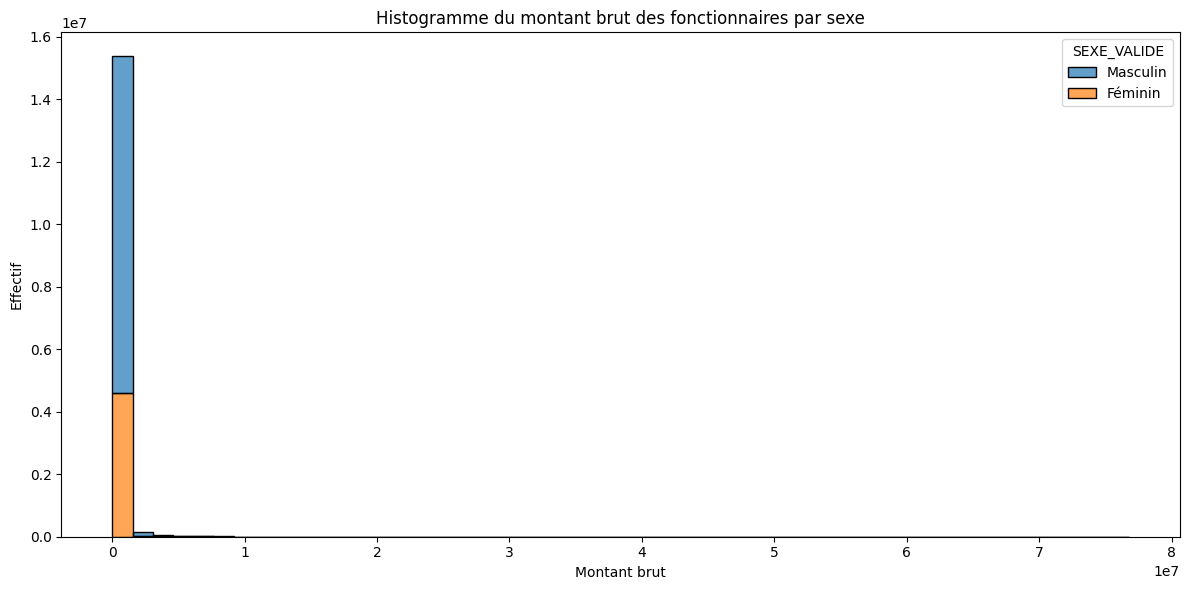

In [62]:

import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer uniquement les fonctionnaires
df_fonctionnaires = panel_solde_df[panel_solde_df["GRADE"].str.contains("Fonctionnaire", na=False)]

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_fonctionnaires,
    x="MONTANT BRUT",
    hue="SEXE_VALIDE",
    multiple="stack",   # ou "dodge" pour histogrammes côte à côte
    bins=50,
    alpha=0.7
)
plt.title("Histogramme du montant brut des fonctionnaires par sexe")
plt.xlabel("Montant brut")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()


## Selon le type d'emplois  

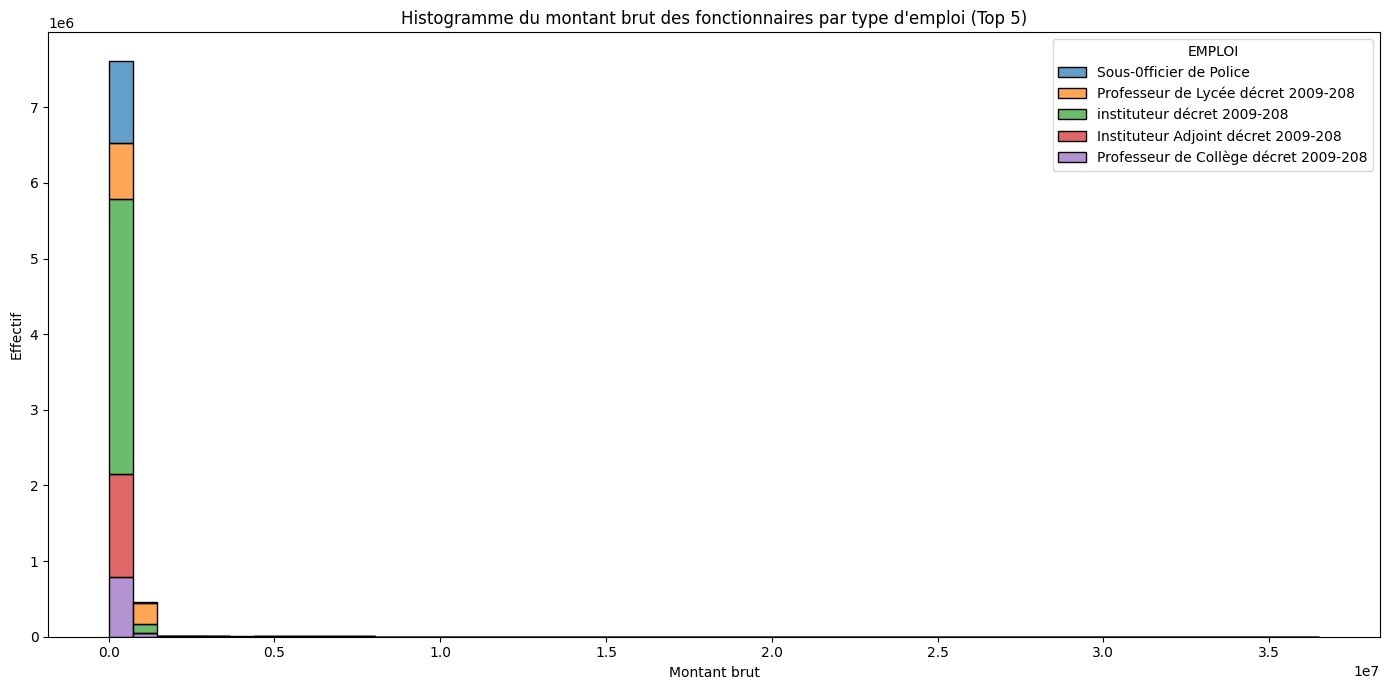

In [63]:
top_emplois = df_fonctionnaires["EMPLOI"].value_counts().index[:5]

plt.figure(figsize=(14, 7))
sns.histplot(
    data=df_fonctionnaires[df_fonctionnaires["EMPLOI"].isin(top_emplois)],
    x="MONTANT BRUT",
    hue="EMPLOI",
    multiple="stack",
    bins=50,
    alpha=0.7
)
plt.title("Histogramme du montant brut des fonctionnaires par type d'emploi (Top 5)")
plt.xlabel("Montant brut")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()



#                              SITUATION                           #                          


In [64]:
# CODE_SITUATION_SOLDE = Situation

**chargement de la base situation**

In [71]:
import boto3
from io import BytesIO
import pandas as pd

# Connexion au client S3 MinIO
s3_client = boto3.client(
    "s3",
    endpoint_url="http://minio.mon-namespace.svc.cluster.local:80",
    aws_access_key_id="wer1Or8j7hXa3QGk2M3M",
    aws_secret_access_key="YtbyBd3Y0bEYeDy8aeX3lAf4JIUlKYlxY8lNVTVt",
    verify=False
)

bucket_name = "admindataanstat"
object_key = "Solde/FICHIER_ANSTAT_CODE_2025.xlsx"

# Récupérer le fichier depuis S3 en mémoire
response = s3_client.get_object(Bucket=bucket_name, Key=object_key)
bytes_io = BytesIO(response['Body'].read())

# Lire la feuille Excel spécifique
df_situation = pd.read_excel(bytes_io, sheet_name="CODE_SITUATION_SOLDE")

print("Colonnes df_situation:", df_situation.columns.tolist())


Colonnes df_situation: ['CODE_POSITION_SOLDE', 'LIBELLÉ_POSITION_SOLDE ( LIBELLE_SITUATION_SOLDE)']


In [72]:
panel_solde_df["SITUATION"].head()

0                 En Activité
1                 En Activité
2                 En Activité
3                 En Activité
4    Retraite pour Limite Age
Name: SITUATION, dtype: object

In [73]:
df_situation.head()

,CODE_POSITION_SOLDE,LIBELLÉ_POSITION_SOLDE ( LIBELLE_SITUATION_SOLDE)
0,0,Annulé
1,1,Prise En Compte En Cours
2,9,Agent en Liquidation de Droits
3,10,En Activité
4,20,Suspendu Sans Solde


**Fusion de la base situation avec la base de travail**

In [74]:
# Merge avec indicateur pour contrôle
tsit = panel_solde_df.merge(
    df_situation[[
        'LIBELLÉ_POSITION_SOLDE ( LIBELLE_SITUATION_SOLDE)',
        'CODE_POSITION_SOLDE'
    ]],
    left_on='SITUATION',
    right_on='LIBELLÉ_POSITION_SOLDE ( LIBELLE_SITUATION_SOLDE)',
    how='left'
)
panel_solde_df = tsit

In [75]:
print(panel_solde_df.columns)

Index(['MATRICULE||CODE_ORGANISME', 'MATRICULE', 'NOM', 'DATE NAISSANCE',
       'SEXE', 'SITUATION MATRIMONIALE', 'NOMBRE ENFANT', 'LIEU AFFECTATION',
       'SERVICE', 'ORGANISME', 'PRISE DE SERVICE', 'SITUATION',
       'DATE DEBUT SITUATION', 'EMPLOI', 'FONCTION', 'GRADE', 'CLASSE/ECHELON',
       'MONTANT BRUT', 'MONTANT NET', 'RETENUE  PENSION', 'IMPOT ',
       'CHARGE PATRONALE', 'MOIS/ANNEE', 'GRADE 2', 'AGE RETRAITE',
       'DATE RETRAITE', 'PERIODE', 'DATE_COLLECTE', 'CODE_ORGANISME',
       'ANNEE_NAISSANCE', 'MOIS_NAISSANCE', 'JOUR_NAISSANCE', 'ANNEE_COLLECTE',
       'MOIS_COLLECTE', 'JOUR_COLLECTE', 'nbre_date_naissances',
       'DATE_NAISSANCE_CORRIGEE', 'ANNEE_NAISSANCE_CORRIGEE',
       'MOIS_NAISSANCE_CORRIGEE', 'JOUR_NAISSANCE_CORRIGEE', 'AGE',
       'AGE_VALIDE', 'SEXE_VALIDE', 'AGE_IMPUTE',
       'SITUATION_MATRIMONIALE_RECODE', 'NBRE_ENFTS_IMPUTE',
       'CODE_LIEU_AFFECTATION', 'MONTANT_TRANSPORT',
       'LIEU_AFFECTATION_CORRIGE', 'CodReg', 'NomReg', 'Cod

**Bilan de la fusion**

In [76]:
print(panel_solde_df['CODE_POSITION_SOLDE'].isna().sum())

0


**Enrégistrement des situations qui n'ont pas de code dans la base de travail**

In [79]:
# Convertir la Series en DataFrame pour l'export
unmatched_sit_df = situation_non_match.reset_index()
unmatched_sit_df.columns = ['SITUATION', 'NBRE']

# Enregistrer dans un fichier Excel local
unmatched_sit_df.to_excel("situation_sans_code.xlsx", index=False)


NameError: name 'situation_non_match' is not defined

In [80]:
# Calcul du salaire moyen par situation
salaire_moyen_par_situation = panel_solde_df.groupby("SITUATION")["MONTANT BRUT"].mean().round(2)

# Créer un tableau combiné avec effectif, pourcentage et salaire moyen
tableau_final = pd.DataFrame({
    "Effectif": tab_sit,
    "Pourcentage (%)": (tab_sit_pct * 100).round(2),
    "Salaire moyen": salaire_moyen_par_situation
})

tableau_final

NameError: name 'tab_sit' is not defined

In [81]:
panel_solde_df["MONTANT BRUT"].describe().round()

count    15627963.0
mean       465586.0
std        546440.0
min           542.0
25%        274176.0
50%        375040.0
75%        514147.0
max      76801094.0
Name: MONTANT BRUT, dtype: float64

In [82]:
tab_mont_brut = panel_solde_df["MONTANT BRUT"].value_counts(dropna=False).sort_index()
tab_mont_brut_pct = panel_solde_df["MONTANT BRUT"].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "Effectif": tab_mont_brut ,
    "Pourcentage (%)": (tab_mont_brut_pct * 100).round(2)
})

,Effectif,Pourcentage (%)
MONTANT BRUT,,
542,1,0.0
1948,1,0.0
2164,1,0.0
2303,1,0.0
2450,1,0.0
...,...,...
46656723,1,0.0
46888230,3,0.0
52375865,1,0.0
